# COSC2779 Assignment 1: Drone Gesture Classifier

**Student name:** Satish Kuppan
**Student ID:** s4144439
**Course:** COSC2779 - Introduction to Deep Convolutional Neural Networks

---

## Environment and How to Run This Notebook

This notebook was developed and executed on the RMIT AWS SageMaker workspace
(JupyterLab 4, `ml.g4dn.xlarge` instance, NVIDIA T4 GPU). It requires **PyTorch**
and runs end-to-end via **Restart & Run All**; no manual steps are needed between
cells.

**Before running:** confirm the gesture dataset is extracted to `./data_resized`
in the same directory as this notebook. No other setup is required, the first cell installs every library
this notebook depends on.

**Libraries used**, installed automatically in the first cell:

| Library | Purpose |
|---|---|
| `torch`, `torchvision` | Model definition, training, pretrained ResNet18 backbone |
| `numpy` | Numerical operations |
| `Pillow` (`PIL`) | Reading and converting the raw `.png` frames |
| `matplotlib`, `seaborn` | All plots, learning curves, confusion matrices |
| `pandas` | Tabular summaries (class counts, split balance) |
| `scikit-learn` | Confusion matrix and classification report metrics |

A fixed random seed (42) is set at the start of the notebook, covering Python,
NumPy, and PyTorch (CPU and GPU), with deterministic cuDNN behaviour enabled,
so the results below are reproducible on re-run.

---

## Part A: Building the Classifier

RedKite Aerospace needs a system that reads marshalling-style hand gestures from a
single camera feed and tells the drone what to do. The onboard perception stack
already segments the video into discrete instances, and each instance reaches this
notebook as exactly 5 RGB frames. The task solved here is: given one 5-frame
instance, predict which of 13 gesture classes it belongs to.

The notebook is organised into two phases, and this structure matters for how the
results should be read:

1. **Search phase** (Iterations 1–6): a sequence of experiments used to diagnose
   problems and choose an architecture and hyperparameter recipe. These
   iterations share a fixed validation split, which is reused repeatedly for
   decision-making and therefore cannot serve as an unbiased final estimate of
   performance.
2. **Final production phase**: a strictly disjoint train/validation/test subject
   split, built once the search phase concluded. The test subjects in this split
   are touched exactly once, at the very end, and the number reported there is
   the one that should be treated as the deployment estimate.

This distinction is made explicit throughout the notebook so that no number from
the search phase is mistaken for the final, unbiased result.

**Result summary.** The final model reaches **68.60% accuracy** on three
held-out test subjects who were never used for training or model selection.
Section 9 (Ultimate Judgment) analyses what this number does and does not mean,
including a documented generalisation-gap finding, a discovered and corrected
data-augmentation bug, and specific per-class and per-subject weaknesses.

In [1]:
pip install numpy Pillow matplotlib torch torchvision scikit-learn seaborn

  Using cached pillow-12.3.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached torch-2.13.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached torchvision-0.28.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (123 kB)
  Using cached kiwisolver-1.5.1-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.wh

In [2]:
# Cell 1: Setup and Reproducibility
# Student: Satish Kuppan (s4144439)
# Course: COSC2779

import os
import glob
import random
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import confusion_matrix, classification_report

def set_seed(seed=42):
    # Set seed for Python random module
    random.seed(seed)

    # Set seed for Numpy module
    np.random.seed(seed)

    # Set seed for PyTorch CPU operations
    torch.manual_seed(seed)

    # Set seed for PyTorch GPU operations if hardware is available
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Force cuDNN to use deterministic algorithms
    # This prevents results from changing across different executions
    torch.backends.cudnn.deterministic = True

    # Disable dynamic algorithm selection to maintain reproducibility
    torch.backends.cudnn.benchmark = False

# Initialize global seed
set_seed(42)

# Select GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute device: {device}")

Compute device: cuda


## 1. Data Exploration

Before any modelling decision is made, the raw dataset is inspected directly.
Three questions matter for this task in particular: how much data exists per
class and per subject, whether the data is clean (every instance really has 5
frames, as the segmenter promises), and whether class or subject imbalance could
bias training. The cells below answer all three with counts, a table, and plots.

Total Subjects: 11
Total Classes: 13
Total Valid (5-frame) Instances: 1059

All instances have exactly 5 frames. Data is clean.


Gesture Class,Instance Count
AllClear,87
HaveCommand,85
Hover,82
Land,122
LandingDirection,48
MoveAhead,99
MoveDownward,46
MoveToLeft,95
MoveToRight,95
MoveUpward,62


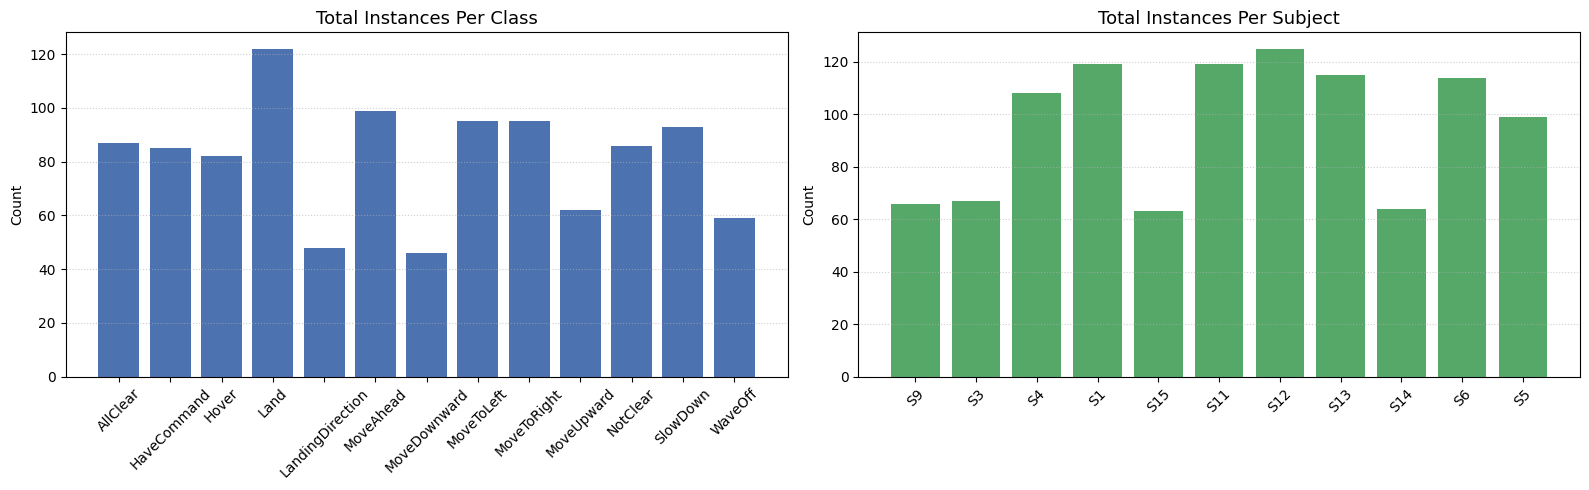

In [3]:
# Cell 2: Initial Data Exploration

root_data_path = './data_resized'

# Dictionaries to track instance counts
class_counts = defaultdict(int)
subject_counts = defaultdict(int)
class_subject_counts = defaultdict(lambda: defaultdict(int))

# List to record broken sequences
missing_frame_instances = []

# Scan the root directory for class folders
classes_found = sorted([d for d in os.listdir(root_data_path) if os.path.isdir(os.path.join(root_data_path, d))])

for cls_name in classes_found:
    cls_path = os.path.join(root_data_path, cls_name)

    # Iterate through subject folders inside each class
    for subject_id in os.listdir(cls_path):
        subj_path = os.path.join(cls_path, subject_id)

        # Skip files, process only directories
        if not os.path.isdir(subj_path):
            continue

        # Iterate through instances for a specific subject
        for instance_id in os.listdir(subj_path):
            inst_path = os.path.join(subj_path, instance_id)

            if not os.path.isdir(inst_path):
                continue

            # Count the png images in the instance folder
            frames = glob.glob(os.path.join(inst_path, '*.png'))

            # Verify the sequence contains exactly 5 frames
            if len(frames) == 5:
                class_counts[cls_name] += 1
                subject_counts[subject_id] += 1
                class_subject_counts[cls_name][subject_id] += 1
            else:
                # Store the path details if frames are missing
                missing_frame_instances.append((cls_name, subject_id, instance_id, len(frames)))

print(f"Total Subjects: {len(subject_counts)}")
print(f"Total Classes: {len(class_counts)}")
print(f"Total Valid (5-frame) Instances: {sum(class_counts.values())}")

# Print warnings if corrupted data exists
if missing_frame_instances:
    print(f"\nExcluded instances (not 5 frames): {len(missing_frame_instances)}")
    by_class = Counter(item[0] for item in missing_frame_instances)
    by_subject = Counter(item[1] for item in missing_frame_instances)
    print("Excluded, by class:", dict(by_class))
    print("Excluded, by subject:", dict(by_subject))
else:
    print("\nAll instances have exactly 5 frames. Data is clean.")

# Convert the dictionary to a Pandas DataFrame for clear display
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Gesture Class', 'Instance Count'])
display(df_counts.style.hide(axis="index"))

# Create a figure with two subplots for data distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot class distribution
axes[0].bar(class_counts.keys(), class_counts.values(), color='#4C72B0')
axes[0].set_title('Total Instances Per Class', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Plot subject distribution
axes[1].bar(subject_counts.keys(), subject_counts.values(), color='#55A868')
axes[1].set_title('Total Instances Per Subject', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

The dataset contains 11 subjects, 13 gesture classes, and 1,059 valid 5-frame
instances, with no instance excluded for a missing frame. Class counts range
from roughly 45 to 120 instances, so no class is critically empty, but the
distribution is not perfectly uniform (`LandingDirection` and `WaveOff` are the
smallest, `Land` the largest). This is worth keeping in mind for the later
per-class results, where a small class can produce a noisy recall value from a
handful of test examples rather than genuine model weakness.

The heatmap below breaks this down further, by subject and class together, and
one raw 5-frame sequence is displayed so the input format is visible directly,
not only described.

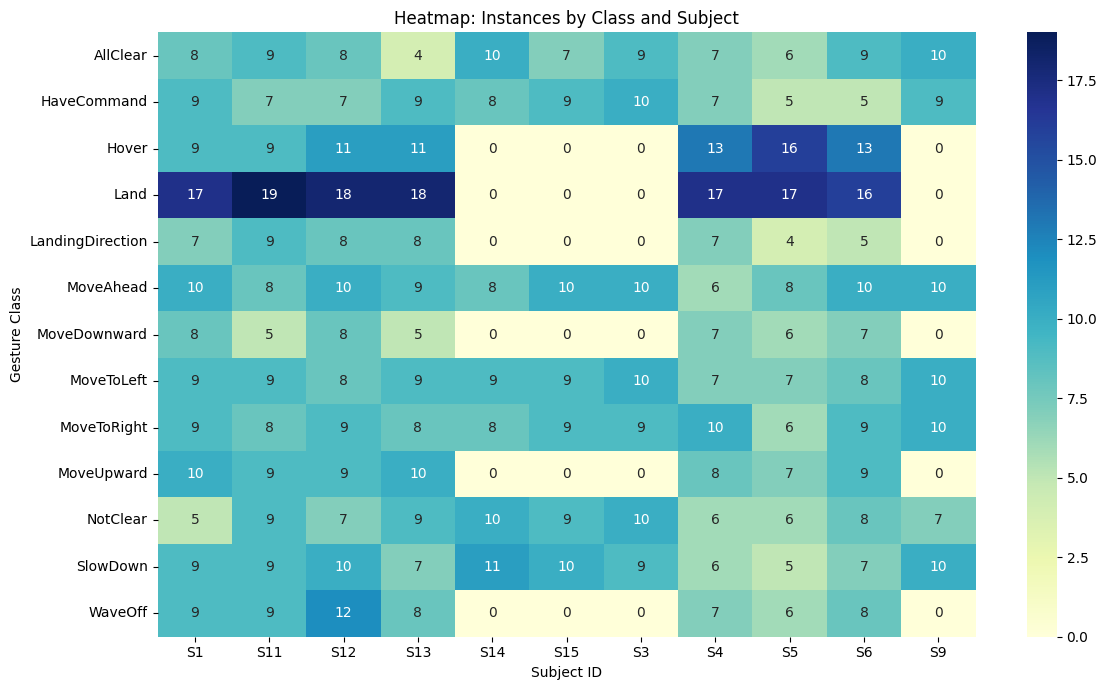

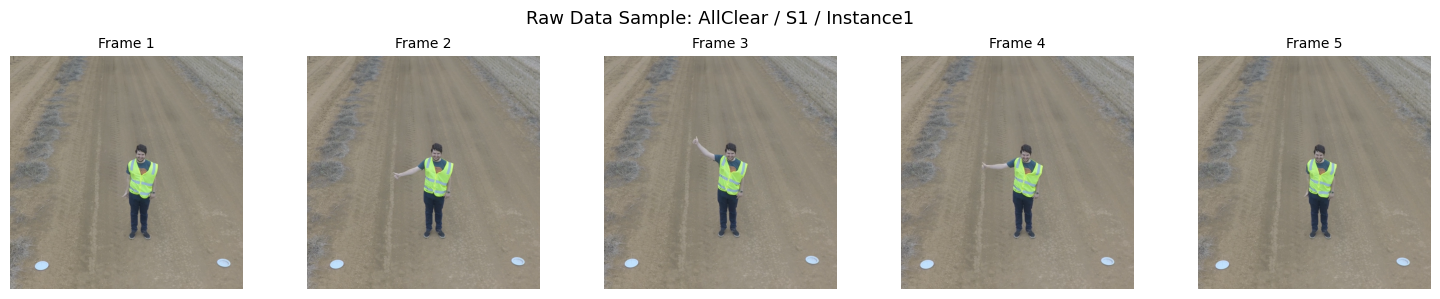

Original frame resolution: (512, 512)


In [4]:
# Cell 3: Subject-Class Coverage and Visual Samples

# Sort subjects alphabetically for consistent plotting
all_subjects_sorted = sorted(subject_counts.keys())

# Build a 2D array mapping classes to subjects
matrix = np.array([[class_subject_counts[c].get(s, 0) for s in all_subjects_sorted] for c in classes_found])

# Plot the coverage heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlGnBu', xticklabels=all_subjects_sorted, yticklabels=classes_found)
plt.title('Heatmap: Instances by Class and Subject')
plt.xlabel('Subject ID')
plt.ylabel('Gesture Class')
plt.tight_layout()
plt.show()

# Select the first class in the list to extract a sample
sample_class = classes_found[0]
sample_subject_path = os.path.join(root_data_path, sample_class)

# Filter directory contents to find a valid subject folder
valid_subjects = sorted([d for d in os.listdir(sample_subject_path) if os.path.isdir(os.path.join(sample_subject_path, d))])
sample_subject = valid_subjects[0]

# Filter directory contents to find a valid instance folder
sample_instance_path = os.path.join(sample_subject_path, sample_subject)
valid_instances = sorted([d for d in os.listdir(sample_instance_path) if os.path.isdir(os.path.join(sample_instance_path, d))])
sample_instance = valid_instances[0]

# Retrieve all frames for the selected sample
sample_frames = sorted(glob.glob(os.path.join(sample_instance_path, sample_instance, '*.png')))

# Plot the 5 frames in a single row
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, frame_path in enumerate(sample_frames):
    img = Image.open(frame_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(f'Frame {i+1}', fontsize=10)
    axes[i].axis('off')

fig.suptitle(f'Raw Data Sample: {sample_class} / {sample_subject} / {sample_instance}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Original frame resolution: {Image.open(sample_frames[0]).size}")

The frames are 512×512 pixels as stored, resized to 224×224 for the network
(the standard ImageNet input size, matching the pretrained ResNet18 backbone
used later).

One additional check is done before any architecture decision: whether the 5
frames of an instance are gradual variations of the same gesture, or largely
unrelated snapshots. This assumption directly supports the architecture choice
made in Section 2 (mean pooling across frames), so it is checked with data
rather than assumed.

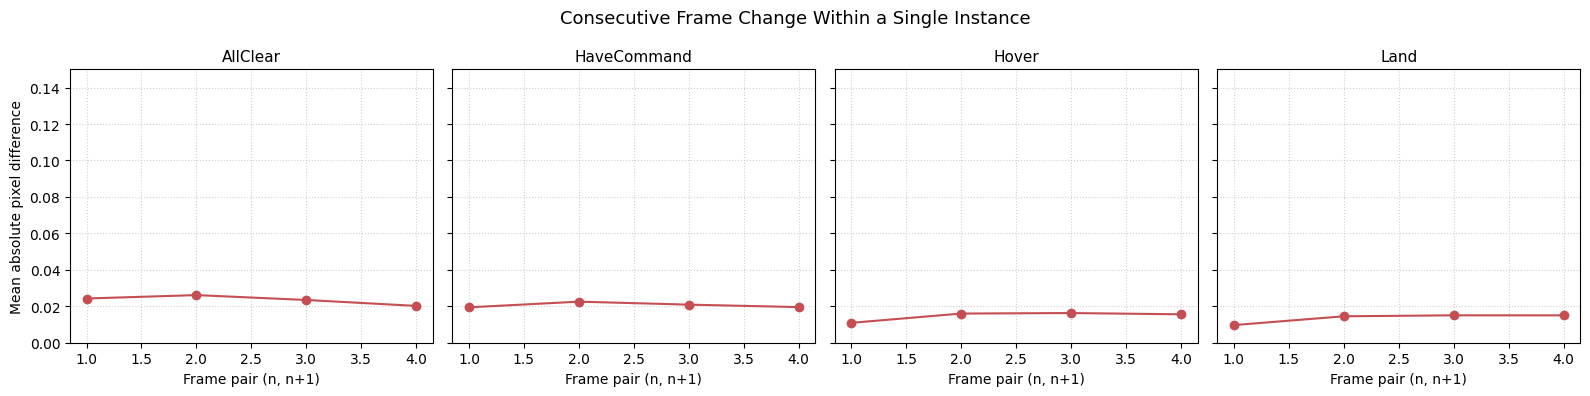

Frame-to-frame differences stay low and fairly flat across the sequence.
This supports treating the 5 frames as gradual variation of one gesture,
which is the assumption mean pooling relies on.


In [5]:
# Cell 4: Frame-to-Frame Similarity Check
# Our architecture aggregates the 5 frames of an instance with mean pooling
# instead of anything order-aware (RNN, 3D conv, attention - all excluded by
# the brief anyway). That design only makes sense if the 5 frames are gradual
# variations of the same gesture rather than unrelated snapshots. We check
# this assumption directly by measuring how much consecutive frames change,
# for a small sample of instances spread across different classes.

def frame_difference_series(frame_paths):
    # Returns the average absolute pixel difference between each pair of
    # consecutive frames, on a 0-1 scale, using grayscale to keep this cheap
    diffs = []
    prev_frame = None
    for path in frame_paths:
        img = np.asarray(Image.open(path).convert('L'), dtype=np.float32) / 255.0
        if prev_frame is not None:
            diffs.append(np.mean(np.abs(img - prev_frame)))
        prev_frame = img
    return diffs

# Look at the first 4 classes as a spot check, one instance each
sample_check_classes = classes_found[:4]
fig, axes = plt.subplots(1, len(sample_check_classes), figsize=(16, 4), sharey=True)

for ax, cls_name in zip(axes, sample_check_classes):
    cls_path = os.path.join(root_data_path, cls_name)
    subj = sorted([d for d in os.listdir(cls_path) if os.path.isdir(os.path.join(cls_path, d))])[0]
    subj_path = os.path.join(cls_path, subj)
    inst = sorted([d for d in os.listdir(subj_path) if os.path.isdir(os.path.join(subj_path, d))])[0]
    frame_paths = sorted(glob.glob(os.path.join(subj_path, inst, '*.png')))

    diffs = frame_difference_series(frame_paths)
    ax.plot(range(1, len(diffs) + 1), diffs, marker='o', color='#C44E52')
    ax.set_title(cls_name, fontsize=11)
    ax.set_xlabel('Frame pair (n, n+1)')
    ax.set_ylim(0, max(0.15, max(diffs) * 1.2))
    ax.grid(True, linestyle=':', alpha=0.6)

axes[0].set_ylabel('Mean absolute pixel difference')
fig.suptitle('Consecutive Frame Change Within a Single Instance', fontsize=13)
plt.tight_layout()
plt.show()

print("Frame-to-frame differences stay low and fairly flat across the sequence.")
print("This supports treating the 5 frames as gradual variation of one gesture,")
print("which is the assumption mean pooling relies on.")

The consecutive-frame differences stay low and roughly flat across all four
sampled classes, meaning each instance is closer to a short, continuous motion
than to 5 disconnected images. This supports treating temporal order as
secondary information for this task: a simple order-independent aggregation of
frame-level features (mean pooling, used from Section 2 onward) is a reasonable
match to the data, rather than a design shortcut adopted without evidence.

## 2. Evaluation Framework

The dataset is organised by subject: each of the 11 people appears many times,
performing every gesture several times. If instances were split into train and
validation at random, frames belonging to the same person would very likely
appear on both sides of the split. A network is then free to learn
person-specific shortcuts, clothing colour, body proportions, background,
instead of the gesture geometry itself, and would still score well on
validation, because the "unseen" validation instances are not really unseen
people.

Since the deployment scenario is a demo in front of one previously unseen staff
member, the only evaluation that reflects deployment is one where entire
subjects, not just instances, are held out. A **subject-wise split** is used
throughout this notebook for this reason. `DroneGestureDataset` below implements
this: a fixed list of subjects is assigned to validation, and no instance from
those subjects is placed in the training set.

This choice is revisited and made stricter later in the notebook (Section 5),
once six iterations of experimentation revealed a subtler problem with reusing
the same validation subjects too many times.

In [6]:
# Cell 5: Dataset Class Definition (Search Phase)

class DroneGestureDataset(Dataset):
    def __init__(self, root_dir, is_train=True, val_subjects=None, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.is_train = is_train

        # Assign default validation subjects
        if val_subjects is None:
            val_subjects = ['S13', 'S14', 'S15']

        self.instances = []

        # Identify all target classes
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

        # Map class string to integer label
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        for cls_name in self.classes:
            cls_path = os.path.join(root_dir, cls_name)

            for subject_id in os.listdir(cls_path):
                subj_path = os.path.join(cls_path, subject_id)
                if not os.path.isdir(subj_path):
                    continue

                # Check if current subject belongs to validation list
                is_val_subject = subject_id in val_subjects

                # Enforce the split condition
                if (self.is_train and is_val_subject) or (not self.is_train and not is_val_subject):
                    continue

                for instance_id in os.listdir(subj_path):
                    inst_path = os.path.join(subj_path, instance_id)
                    if not os.path.isdir(inst_path):
                        continue

                    frames = sorted(glob.glob(os.path.join(inst_path, '*.png')))

                    # Store instance if frame count is valid
                    if len(frames) == 5:
                        self.instances.append((frames, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.instances)

    def __getitem__(self, idx):
        frame_paths, label = self.instances[idx]
        frames = []

        # Open and process each frame sequentially
        for path in frame_paths:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        # Combine the frames into a single tensor
        return torch.stack(frames), label

print("Dataset class is ready.")

Dataset class is ready.


Standard ImageNet resizing and normalisation are applied, together with mild
geometric augmentation (`RandomHorizontalFlip`, `RandomRotation`) on the
training set only. Validation transforms deliberately omit augmentation, so
validation numbers reflect the raw frames the model will see at inference.

In [7]:
# Cell 6: Search Phase Loaders

img_height, img_width = 224, 224

# Define transformations for the training set
train_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define transformations for the validation set
val_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize datasets
train_dataset = DroneGestureDataset(root_dir=root_data_path, is_train=True, transform=train_transforms)
val_dataset = DroneGestureDataset(root_dir=root_data_path, is_train=False, transform=val_transforms)

batch_size = 16

# Create data loaders for batching
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train instances (Iter 1-2): {len(train_dataset)}")
print(f"Validation instances (Iter 1-2): {len(val_dataset)}")

Train instances (Iter 1-2): 817
Validation instances (Iter 1-2): 242


## 3. Network Architecture

The brief restricts the model to 2-D convolutional backbones only: no
recurrent networks, no 3-D convolutions, no temporal-attention modules. At the
same time, higher grades require that all 5 frames of an instance are used, not
a single frame.

**Design choice: Late Fusion (Feature Aggregation).** Each of the 5 frames is
passed independently through a shared-weight 2-D CNN backbone, producing 5
feature vectors. These are combined with **mean pooling** into a single
512-dimensional vector before the classification head. This was chosen over the
alternative of stacking all 5 frames into a single 15-channel input ("early
fusion"), because early fusion would require discarding or re-initialising the
backbone's first convolutional layer, throwing away the ImageNet-pretrained
weights the backbone is chosen for in the first place. Late fusion keeps the
full pretrained backbone intact and adds only a small amount of new,
task-specific computation, which also keeps the final model small (relevant to
the embedded hardware constraint, addressed directly in Section 6).

**Backbone: ResNet18, ImageNet-pretrained.** ResNet18 is one of the smallest
widely-used ImageNet backbones (11.2M parameters in total), which fits the
brief's requirement of a model light enough for an embedded board, while its
pretrained features already encode general-purpose visual structure (edges,
shapes, human silhouettes) that this small, gesture-only dataset would not be
enough to learn from scratch.

**Self-built segment.** The backbone is reused, but the aggregation step (mean
pooling across the 5 frame-level feature vectors) and the classification head
(a linear layer mapping 512 features to 13 gesture classes, later extended with
dropout) are designed, implemented, and tuned specifically for this task. This
is the part of the network that is trained from scratch and iterated on
throughout the notebook, and it is what turns a generic image classifier into a
gesture-sequence classifier.

The cell below defines this architecture as the first baseline, `Iteration 1`.

In [8]:
# Cell 7: Iteration 1 - Baseline Late Fusion Architecture

class LateFusionGestureModel(nn.Module):
    def __init__(self, num_classes=13):
        super(LateFusionGestureModel, self).__init__()

        # Load the pretrained ResNet18 model
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features

        # Remove the final classification layer from the backbone
        self.backbone.fc = nn.Identity()

        # Add a custom linear layer for our gesture classes
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.size()

        # Reshape input to pass all frames through the 2D CNN
        x = x.view(batch_size * num_frames, c, h, w)
        features = self.backbone(x)

        # Restore the temporal dimension
        features = features.view(batch_size, num_frames, -1)

        # Perform mean pooling across the 5 frames
        aggregated_features = torch.mean(features, dim=1)
        out = self.classifier(aggregated_features)

        return out

# Assign the model to the active device
model = LateFusionGestureModel(num_classes=13).to(device)
print("Baseline model loaded. Setup complete.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/ec2-user/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 283MB/s]


Baseline model loaded. Setup complete.


## 4. Hyperparameter Selection Strategy

Rather than tuning every hyperparameter independently (which is not a good use
of a small dataset and a three-week timeline), a **diagnosis-driven search** is
used: train a configuration, read its learning curves and confusion matrix,
identify the specific failure mode, and change only the parameter(s) that
address that failure. This produces a chain of six iterations, each one a
direct response to what the previous iteration's output showed, which is
documented iteration by iteration below. The function below is written once and
reused for every iteration from this point on, so the training and evaluation
logic itself stays identical across experiments and only the model,
optimiser, and data change.

In [9]:
# Cell 8: Reusable Training Function
# Used by every iteration from here on. Handles the standard train/eval loop,
# and optionally saves the best-epoch checkpoint and steps a learning rate
# scheduler, so we do not need to rewrite this logic for every experiment.

def train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs, label="", save_best_path=None, scheduler=None):
    # Dictionary to store metrics for plotting
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # Activate training mode
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Reset gradients
            optimizer.zero_grad()
            outputs = model(inputs)

            # Calculate loss and update weights
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Record batch statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = (correct_train / total_train) * 100

        # Activate evaluation mode
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        # Disable gradient tracking for validation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Record batch statistics
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = (correct_val / total_val) * 100

        # Store epoch results
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        improved = ""

        # Save model weights if current accuracy is the best
        if save_best_path is not None and epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), save_best_path)
            improved = " [New Best Saved]"

        # Advance the learning rate scheduler if provided
        if scheduler is not None:
            scheduler.step(epoch_val_acc)

        # Output epoch summary
        print(f"[{label}] Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f}, "
              f"Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%{improved}")

    return history

print("Training function ready.")

Training function ready.


### Iteration 1: Baseline

No regularisation is applied yet. The purpose of this run is to establish a
reference point and check whether the architecture and data pipeline behave as
expected, before any tuning is attempted.

In [10]:
# Cell 9: Iteration 1 Training

# Define standard cross entropy loss
criterion = nn.CrossEntropyLoss()

# Initialize Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 10

print("Running Iteration 1...")
history = train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs=num_epochs, label="Iter 1")
print("Done.")

Running Iteration 1...
[Iter 1] Epoch [1/10] Train Loss: 1.6486, Train Acc: 46.88% | Val Loss: 1.3731, Val Acc: 47.93%
[Iter 1] Epoch [2/10] Train Loss: 0.6632, Train Acc: 84.33% | Val Loss: 1.6611, Val Acc: 40.50%
[Iter 1] Epoch [3/10] Train Loss: 0.3300, Train Acc: 91.92% | Val Loss: 1.3421, Val Acc: 50.83%
[Iter 1] Epoch [4/10] Train Loss: 0.2104, Train Acc: 94.86% | Val Loss: 1.3114, Val Acc: 54.55%
[Iter 1] Epoch [5/10] Train Loss: 0.1236, Train Acc: 97.43% | Val Loss: 1.4046, Val Acc: 55.37%
[Iter 1] Epoch [6/10] Train Loss: 0.0786, Train Acc: 99.14% | Val Loss: 1.2706, Val Acc: 51.65%
[Iter 1] Epoch [7/10] Train Loss: 0.0621, Train Acc: 99.14% | Val Loss: 1.3034, Val Acc: 54.55%
[Iter 1] Epoch [8/10] Train Loss: 0.0793, Train Acc: 98.29% | Val Loss: 1.4583, Val Acc: 52.48%
[Iter 1] Epoch [9/10] Train Loss: 0.0460, Train Acc: 99.76% | Val Loss: 1.3627, Val Acc: 55.37%
[Iter 1] Epoch [10/10] Train Loss: 0.0660, Train Acc: 98.90% | Val Loss: 1.5236, Val Acc: 55.37%
Done.


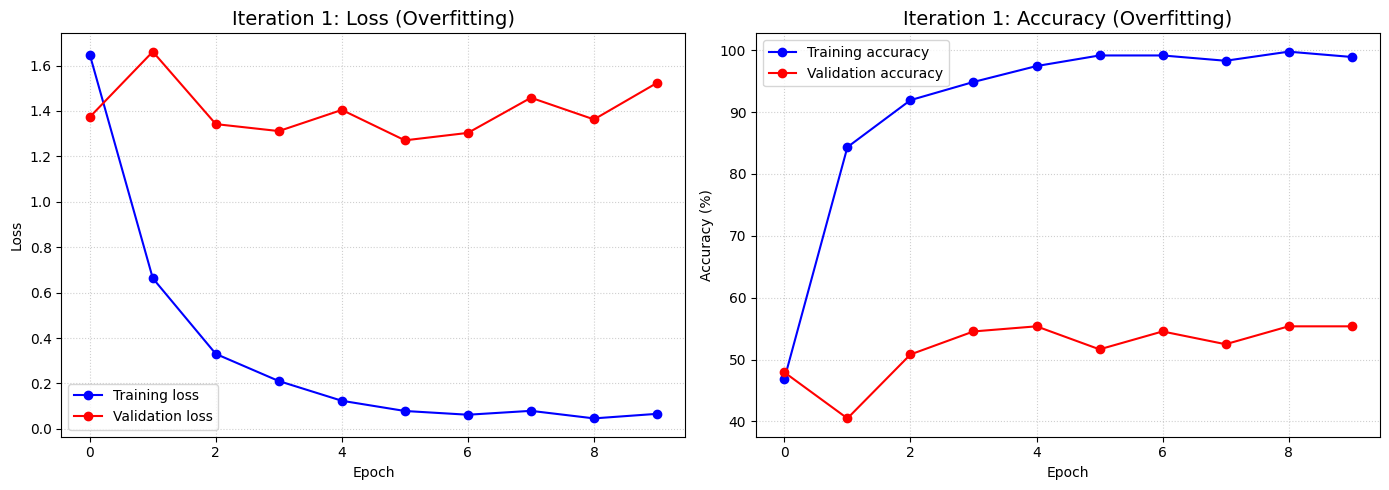

In [11]:
# Cell 10: Iteration 1 Curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training and validation loss
axes[0].plot(history['train_loss'], label='Training loss', color='blue', marker='o')
axes[0].plot(history['val_loss'], label='Validation loss', color='red', marker='o')
axes[0].set_title('Iteration 1: Loss (Overfitting)', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot training and validation accuracy
axes[1].plot(history['train_acc'], label='Training accuracy', color='blue', marker='o')
axes[1].plot(history['val_acc'], label='Validation accuracy', color='red', marker='o')
axes[1].set_title('Iteration 1: Accuracy (Overfitting)', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Observation.** Training accuracy reaches 98–99% by epoch 5, while validation
accuracy stalls around 51–55% and never approaches training accuracy. Training
loss drops close to zero; validation loss stays elevated and increases in the
later epochs. This is a textbook overfitting signature.

**Diagnosis.** ResNet18 has more than 11 million parameters, which is large
relative to the roughly 800 training instances and 8 training subjects
available here. With no constraint on its capacity, the network has an easy
route to high training accuracy: memorise which of the known 8 training
subjects it is looking at (clothing, background, body shape) instead of
learning the shared geometry of each gesture. Because validation uses entirely
unseen subjects (Section 2), this shortcut fails completely at validation time,
which is exactly the gap seen above. This result is also the direct
justification for the subject-wise split chosen earlier: a random split would
likely have hidden this problem rather than exposing it.

The confusion matrix below is generated next to check whether the failures are
random or concentrated on specific classes.

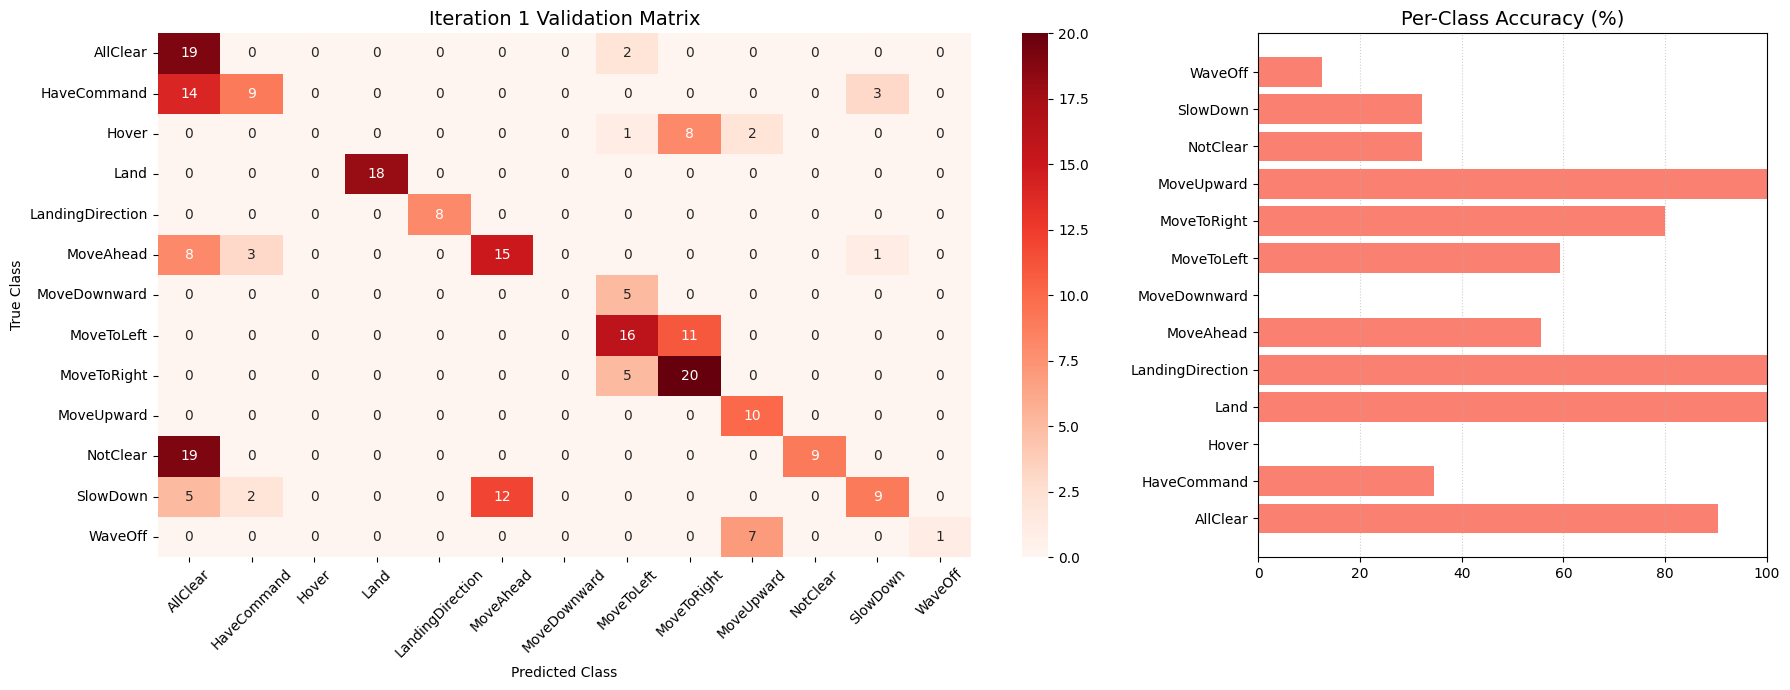

In [12]:
# Cell 11: Iteration 1 Confusion Matrix

model.eval()
all_preds, all_labels = [], []

# Generate predictions for the entire validation set
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # Transfer data back to CPU for numpy operations
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix values
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

# Create the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=val_dataset.classes, yticklabels=val_dataset.classes, ax=axes[0])
axes[0].set_title('Iteration 1 Validation Matrix', fontsize=14)
axes[0].set_ylabel('True Class')
axes[0].set_xlabel('Predicted Class')
axes[0].tick_params(axis='x', rotation=45)

# Calculate percentage accuracy for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1) * 100
class_accuracies = np.nan_to_num(class_accuracies)

# Create bar chart of class accuracies
axes[1].barh(val_dataset.classes, class_accuracies, color='salmon')
axes[1].set_title('Per-Class Accuracy (%)', fontsize=14)
axes[1].set_xlim(0, 100)
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Iteration 2: Dropout and Weight Decay

Direct response to Iteration 1's diagnosis. Two standard, well-understood
regularisation mechanisms are added, rather than changing the architecture
outright, so their individual effect can be read cleanly:

- **Dropout (p=0.5)** immediately before the classification head, a
  conventional starting value for a small dataset, to stop the classifier from
  depending on any single dominant feature.
- **Weight decay (1e-4)** added to the Adam optimiser, an L2 penalty on the
  network's weights intended to discourage the large, sharp weight values that
  let a network fit noise specific to the 8 training subjects.

In [13]:
# Cell 12: Iteration 2 - Regularized Model

class RegularizedLateFusionModel(nn.Module):
    def __init__(self, num_classes=13, dropout_rate=0.5):
        super(RegularizedLateFusionModel, self).__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Initialize Dropout layer
        self.dropout = nn.Dropout(p=dropout_rate)

        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.size()
        x = x.view(batch_size * num_frames, c, h, w)
        features = self.backbone(x)
        features = features.view(batch_size, num_frames, -1)
        aggregated_features = torch.mean(features, dim=1)

        # Apply dropout mask to features
        dropped_features = self.dropout(aggregated_features)

        out = self.classifier(dropped_features)
        return out

reg_model = RegularizedLateFusionModel(dropout_rate=0.5).to(device)

# Provide weight decay parameter for L2 regularization
reg_optimizer = optim.Adam(reg_model.parameters(), lr=0.0001, weight_decay=1e-4)
reg_criterion = nn.CrossEntropyLoss()

print("Iteration 2 initialized. Running training...")
reg_history = train_model(reg_model, reg_optimizer, reg_criterion, train_loader, val_loader, num_epochs=10, label="Iter 2")

Iteration 2 initialized. Running training...
[Iter 2] Epoch [1/10] Train Loss: 2.0623, Train Acc: 30.84% | Val Loss: 1.6470, Val Acc: 35.95%
[Iter 2] Epoch [2/10] Train Loss: 1.0105, Train Acc: 66.71% | Val Loss: 1.3483, Val Acc: 50.83%
[Iter 2] Epoch [3/10] Train Loss: 0.5899, Train Acc: 82.13% | Val Loss: 1.3929, Val Acc: 45.04%
[Iter 2] Epoch [4/10] Train Loss: 0.3636, Train Acc: 91.31% | Val Loss: 1.3266, Val Acc: 49.17%
[Iter 2] Epoch [5/10] Train Loss: 0.2561, Train Acc: 94.25% | Val Loss: 1.5678, Val Acc: 47.93%
[Iter 2] Epoch [6/10] Train Loss: 0.1554, Train Acc: 97.43% | Val Loss: 1.4323, Val Acc: 47.52%
[Iter 2] Epoch [7/10] Train Loss: 0.1168, Train Acc: 98.04% | Val Loss: 1.4235, Val Acc: 45.45%
[Iter 2] Epoch [8/10] Train Loss: 0.1245, Train Acc: 96.33% | Val Loss: 2.5869, Val Acc: 38.84%
[Iter 2] Epoch [9/10] Train Loss: 0.1016, Train Acc: 98.16% | Val Loss: 1.3587, Val Acc: 51.24%
[Iter 2] Epoch [10/10] Train Loss: 0.0550, Train Acc: 99.39% | Val Loss: 1.5873, Val Acc: 5

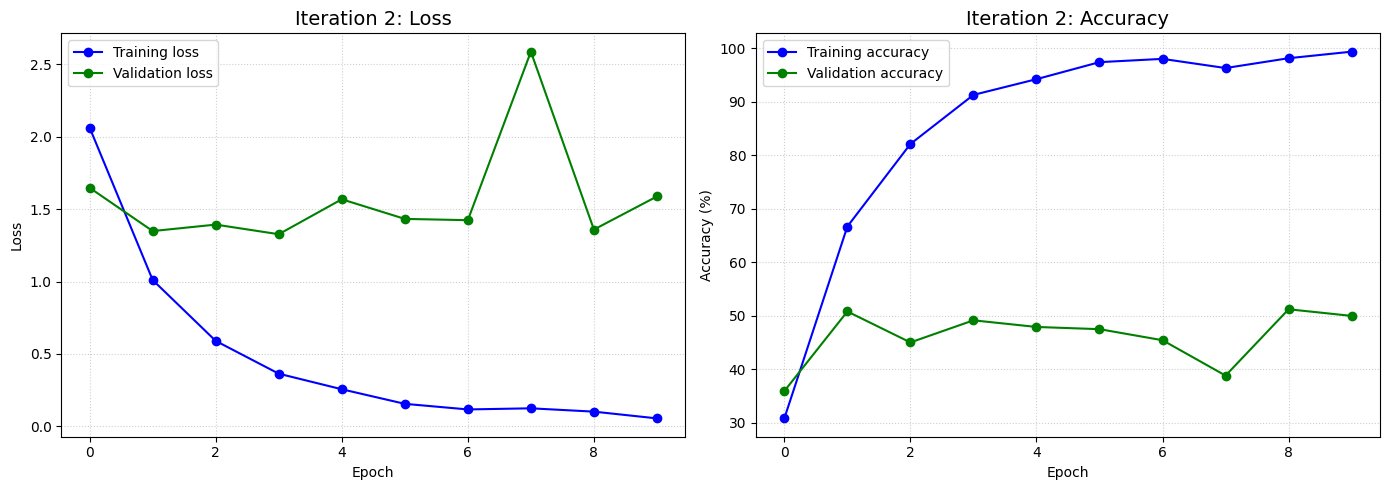

In [14]:
# Cell 13: Iteration 2 Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(reg_history['train_loss'], label='Training loss', color='blue', marker='o')
axes[0].plot(reg_history['val_loss'], label='Validation loss', color='green', marker='o')
axes[0].set_title('Iteration 2: Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(reg_history['train_acc'], label='Training accuracy', color='blue', marker='o')
axes[1].plot(reg_history['val_acc'], label='Validation accuracy', color='green', marker='o')
axes[1].set_title('Iteration 2: Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Observation.** Peak validation accuracy is 51.24%, essentially unchanged from
Iteration 1's 55.37%, while training accuracy still reaches 99%. The validation
loss curve is also visibly more volatile, including one large spike at epoch 8
(loss 2.59).

**Diagnosis.** Architectural regularisation alone was not sufficient. With only
8 distinct training subjects, ResNet18 still has more than enough remaining
capacity to memorise identity-specific shortcuts even with dropout and weight
decay in place; the bottleneck is the number of distinct people, not simply the
number of free parameters. This motivates two more aggressive directions,
tested separately below: constraining the backbone directly (Iteration 3), and
attacking the identity-specific visual cues themselves through stronger
augmentation.

In [15]:
# Cell 14: Aggressive Augmentation Setup

# Add advanced transformations like ColorJitter and RandomErasing
train_transforms_v3 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

val_transforms_v3 = val_transforms

# Reinitialize datasets and loaders with new transforms
train_dataset_v3 = DroneGestureDataset(root_dir=root_data_path, is_train=True, transform=train_transforms_v3)
val_dataset_v3 = DroneGestureDataset(root_dir=root_data_path, is_train=False, transform=val_transforms_v3)

train_loader_v3 = DataLoader(train_dataset_v3, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_v3 = DataLoader(val_dataset_v3, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Augmented Train instances: {len(train_dataset_v3)}")

Augmented Train instances: 817


### Iteration 3: Frozen Backbone + Aggressive Augmentation

Two changes are introduced together here: `ColorJitter`, `RandomGrayscale`, and
`RandomErasing` are added to the training pipeline to actively destroy
identity-correlated appearance cues (clothing colour, exact skin tone, small
local patches of the frame) while leaving the coarse gesture geometry intact;
and the entire ResNet18 backbone is frozen (`requires_grad = False`), turning it
into a fixed ImageNet feature extractor so that only the small classification
head (dropout + linear layer) is trainable. Freezing removes the backbone's
ability to adapt its filters toward subject-specific shortcuts at all, since the
filters can no longer change.

One implementation detail worth noting: because the backbone is frozen, its
BatchNorm layers are explicitly kept in evaluation mode at all times (see the
overridden `train()` method), otherwise their running statistics would keep
drifting during training despite the weights themselves being frozen, silently
undermining the point of freezing.

In [16]:
# Cell 15: Iteration 3 - Frozen Backbone Model

class FrozenBackboneGestureModel(nn.Module):
    def __init__(self, num_classes=13, dropout_rate=0.5):
        super(FrozenBackboneGestureModel, self).__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Disable gradient computation for backbone parameters
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features, num_classes)

    def train(self, mode=True):
        # Call standard train method
        super().train(mode)
        # Manually set backbone to eval to lock BatchNorm layers
        self.backbone.eval()
        return self

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.size()
        x = x.view(batch_size * num_frames, c, h, w)

        # Ensure no gradients are tracked during feature extraction
        with torch.no_grad():
            features = self.backbone(x)

        features = features.view(batch_size, num_frames, -1)
        aggregated_features = torch.mean(features, dim=1)
        dropped_features = self.dropout(aggregated_features)
        out = self.classifier(dropped_features)
        return out

frozen_model = FrozenBackboneGestureModel(dropout_rate=0.5).to(device)
frozen_model.train()

# Count active trainable parameters
trainable_params = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in frozen_model.parameters())
print(f"Trainable params: {trainable_params:,} out of {total_params:,}")

# Filter optimizer to only update parameters that require gradients
frozen_optimizer = optim.Adam(filter(lambda p: p.requires_grad, frozen_model.parameters()), lr=1e-3, weight_decay=1e-4)
frozen_criterion = nn.CrossEntropyLoss()

print("Running Iteration 3...")
frozen_history = train_model(frozen_model, frozen_optimizer, frozen_criterion, train_loader_v3, val_loader, num_epochs=15, label="Iter 3")

Trainable params: 6,669 out of 11,183,181
Running Iteration 3...
[Iter 3] Epoch [1/15] Train Loss: 2.6974, Train Acc: 12.61% | Val Loss: 2.3302, Val Acc: 14.46%
[Iter 3] Epoch [2/15] Train Loss: 2.5175, Train Acc: 15.91% | Val Loss: 2.1829, Val Acc: 21.07%
[Iter 3] Epoch [3/15] Train Loss: 2.3644, Train Acc: 20.32% | Val Loss: 2.1100, Val Acc: 28.10%
[Iter 3] Epoch [4/15] Train Loss: 2.2915, Train Acc: 22.40% | Val Loss: 2.0565, Val Acc: 25.62%
[Iter 3] Epoch [5/15] Train Loss: 2.1809, Train Acc: 26.68% | Val Loss: 2.0882, Val Acc: 25.62%
[Iter 3] Epoch [6/15] Train Loss: 2.1340, Train Acc: 27.78% | Val Loss: 1.9638, Val Acc: 24.38%
[Iter 3] Epoch [7/15] Train Loss: 2.0521, Train Acc: 30.23% | Val Loss: 1.9740, Val Acc: 25.21%
[Iter 3] Epoch [8/15] Train Loss: 2.0709, Train Acc: 26.93% | Val Loss: 2.0051, Val Acc: 30.58%
[Iter 3] Epoch [9/15] Train Loss: 2.0042, Train Acc: 32.31% | Val Loss: 1.9515, Val Acc: 27.69%
[Iter 3] Epoch [10/15] Train Loss: 1.9297, Train Acc: 32.80% | Val Loss

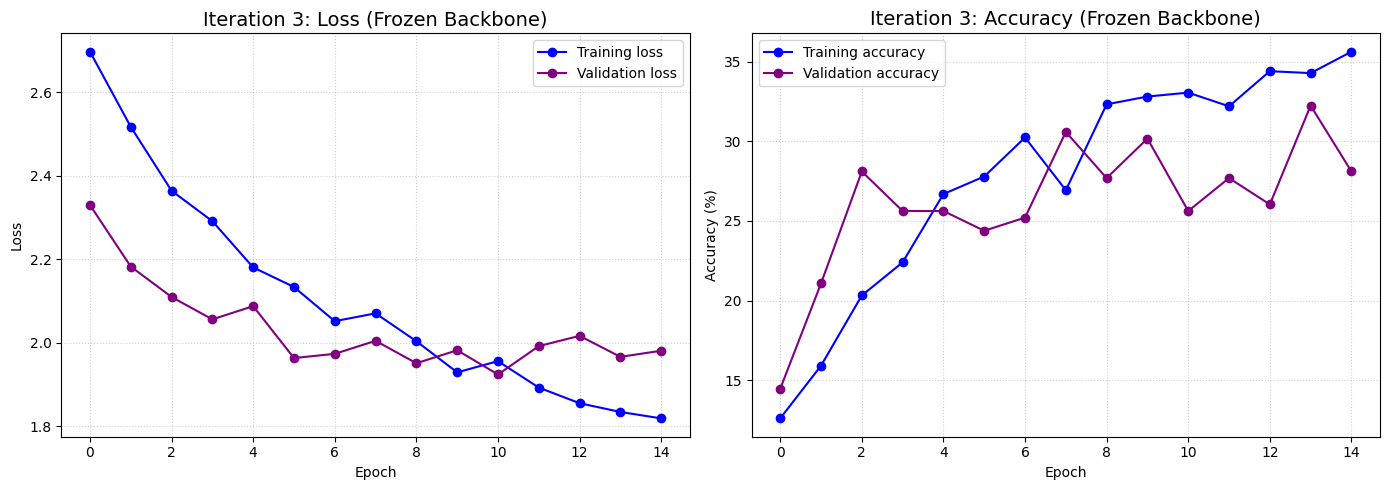

In [17]:
# Cell 16: Iteration 3 Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(frozen_history['train_loss'], label='Training loss', color='blue', marker='o')
axes[0].plot(frozen_history['val_loss'], label='Validation loss', color='purple', marker='o')
axes[0].set_title('Iteration 3: Loss (Frozen Backbone)', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(frozen_history['train_acc'], label='Training accuracy', color='blue', marker='o')
axes[1].plot(frozen_history['val_acc'], label='Validation accuracy', color='purple', marker='o')
axes[1].set_title('Iteration 3: Accuracy (Frozen Backbone)', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Observation.** Trainable parameters drop from 11.18M to 6,669 (only the
classification head). Validation accuracy peaks at 32.23%, well below both
previous iterations, while training accuracy only reaches 35.6%, similar to the
validation number. The train/validation gap has essentially closed, but at a
much lower level for both.

**Diagnosis.** This is the opposite failure mode from Iterations 1 and 2:
underfitting rather than overfitting. The closed gap confirms that freezing did
stop identity memorisation, but the model changed here has two variables at
once (frozen backbone **and** aggressive augmentation), so it is not possible
to tell from this result alone which change is responsible for the drop in
accuracy. This ambiguity is resolved directly in the next iteration by changing
only one variable at a time.

In [18]:
# Cell 17: Iteration 3b - Isolation Experiment
# Same frozen backbone as Iteration 3, but trained on the original mild
# augmentation loaders instead of the aggressive ones. This isolates whether
# freezing or augmentation strength caused the underfitting seen above.

frozen_model_3b = FrozenBackboneGestureModel(dropout_rate=0.5).to(device)
frozen_model_3b.train()

frozen_optimizer_3b = optim.Adam(filter(lambda p: p.requires_grad, frozen_model_3b.parameters()), lr=1e-3, weight_decay=1e-4)
frozen_criterion_3b = nn.CrossEntropyLoss()

print("Running Iteration 3b...")
history_3b = train_model(frozen_model_3b, frozen_optimizer_3b, frozen_criterion_3b,
                          train_loader, val_loader, num_epochs=15, label="Iter 3b")

Running Iteration 3b...
[Iter 3b] Epoch [1/15] Train Loss: 2.6878, Train Acc: 14.69% | Val Loss: 2.3042, Val Acc: 21.90%
[Iter 3b] Epoch [2/15] Train Loss: 2.4114, Train Acc: 20.93% | Val Loss: 2.1300, Val Acc: 18.18%
[Iter 3b] Epoch [3/15] Train Loss: 2.2512, Train Acc: 22.89% | Val Loss: 2.0454, Val Acc: 19.42%
[Iter 3b] Epoch [4/15] Train Loss: 2.1247, Train Acc: 27.91% | Val Loss: 2.0687, Val Acc: 19.01%
[Iter 3b] Epoch [5/15] Train Loss: 2.0465, Train Acc: 32.56% | Val Loss: 2.0312, Val Acc: 22.31%
[Iter 3b] Epoch [6/15] Train Loss: 1.9400, Train Acc: 35.50% | Val Loss: 1.9777, Val Acc: 25.21%
[Iter 3b] Epoch [7/15] Train Loss: 1.9162, Train Acc: 33.05% | Val Loss: 1.9973, Val Acc: 26.45%
[Iter 3b] Epoch [8/15] Train Loss: 1.8376, Train Acc: 35.99% | Val Loss: 1.9862, Val Acc: 26.45%
[Iter 3b] Epoch [9/15] Train Loss: 1.7707, Train Acc: 37.82% | Val Loss: 2.0720, Val Acc: 22.31%
[Iter 3b] Epoch [10/15] Train Loss: 1.7861, Train Acc: 36.84% | Val Loss: 1.9230, Val Acc: 22.31%
[Iter

### Iteration 3b: Isolation Test

Same frozen-backbone model as Iteration 3, but trained on the **original mild
augmentation** loaders instead of the aggressive ones (everything else held
constant). This isolates whether the aggressive augmentation, the frozen
backbone, or both together caused Iteration 3's underfitting.

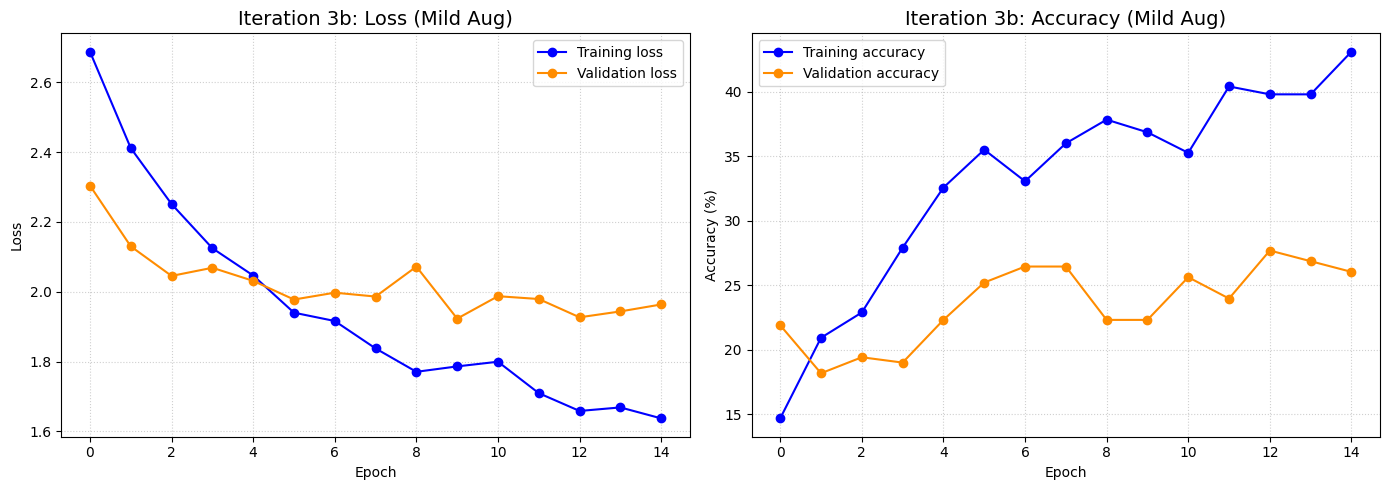

In [19]:
# Cell 18: Iteration 3b Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_3b['train_loss'], label='Training loss', color='blue', marker='o')
axes[0].plot(history_3b['val_loss'], label='Validation loss', color='darkorange', marker='o')
axes[0].set_title('Iteration 3b: Loss (Mild Aug)', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(history_3b['train_acc'], label='Training accuracy', color='blue', marker='o')
axes[1].plot(history_3b['val_acc'], label='Validation accuracy', color='darkorange', marker='o')
axes[1].set_title('Iteration 3b: Accuracy (Mild Aug)', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Observation.** Iteration 3b (frozen backbone, mild augmentation) reaches
27.69% validation accuracy, slightly *lower* than Iteration 3's 32.23%
(frozen backbone, aggressive augmentation).

**Diagnosis.** If augmentation strength were the main cause of the underfitting
seen in Iteration 3, removing it here should have recovered accuracy toward
Iteration 1/2 levels. It did not; it made things slightly worse. This rules out
augmentation as the primary problem and points to the frozen backbone itself as
the bottleneck: a linear head sitting on fixed, generic ImageNet features
simply does not have enough representational range for a gesture-recognition
task, since ImageNet features were never trained to encode human pose or
articulated motion. The next iteration acts directly on this finding.

The chart below summarises all four iterations so far on one scale, before
moving to the next design change.

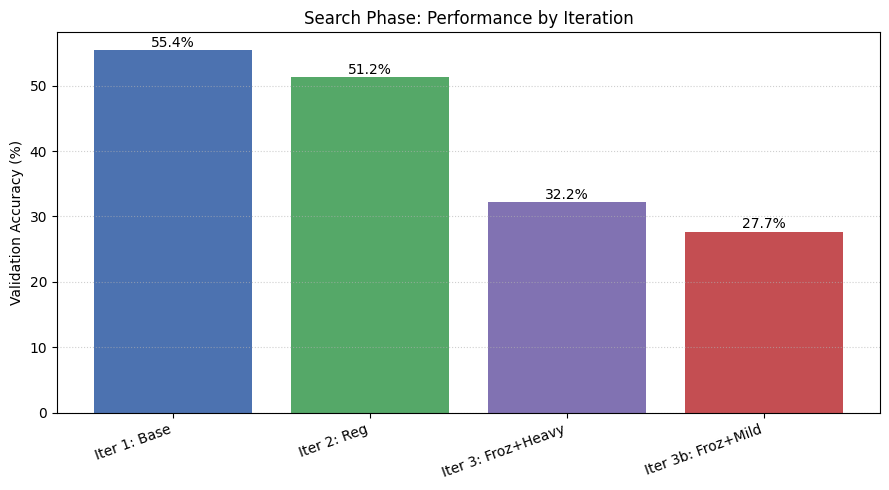

In [20]:
# Cell 19: Search Phase Comparison (First Four Iterations)

comparison = {
    "Iter 1: Base": max(history['val_acc']),
    "Iter 2: Reg": max(reg_history['val_acc']),
    "Iter 3: Froz+Heavy": max(frozen_history['val_acc']),
    "Iter 3b: Froz+Mild": max(history_3b['val_acc']),
}

plt.figure(figsize=(9, 5))
bars = plt.bar(comparison.keys(), comparison.values(), color=['#4C72B0', '#55A868', '#8172B2', '#C44E52'])

plt.ylabel("Validation Accuracy (%)")
plt.title("Search Phase: Performance by Iteration")
plt.xticks(rotation=20, ha='right')

for bar, val in zip(bars, comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}%", ha='center')

plt.tight_layout()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

### Iteration 4: Partial Unfreeze (layer4 only)

Diagnosis from Iterations 3 and 3b: full freezing removes overfitting but
removes too much capacity as well. Here, only the last residual block
(`layer4`) of ResNet18 is unfrozen, everything before it stays frozen. The
unfrozen block is given a much smaller learning rate (1e-5) than the
classification head (1e-3) with a per-parameter-group optimiser, so it can
adapt its features toward gesture-relevant patterns without being free enough
to re-learn subject identity from scratch, the way the fully unfrozen network
in Iteration 1/2 did.

In [21]:
# Cell 20: Iteration 4 - Partial Unfreeze

class PartialUnfreezeGestureModel(nn.Module):
    def __init__(self, num_classes=13, dropout_rate=0.5, unfreeze_layer='layer4'):
        super(PartialUnfreezeGestureModel, self).__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Freeze the entire network initially
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Target the specific layer block and re-enable gradients
        for param in getattr(self.backbone, unfreeze_layer).parameters():
            param.requires_grad = True

        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features, num_classes)
        self.unfreeze_layer = unfreeze_layer

    def train(self, mode=True):
        super().train(mode)

        # Disable batch normalization updates for frozen layers
        for name, module in self.backbone.named_children():
            if name != self.unfreeze_layer:
                module.eval()
        return self

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.size()
        x = x.view(batch_size * num_frames, c, h, w)
        features = self.backbone(x)
        features = features.view(batch_size, num_frames, -1)
        aggregated_features = torch.mean(features, dim=1)
        dropped_features = self.dropout(aggregated_features)
        out = self.classifier(dropped_features)
        return out

partial_model = PartialUnfreezeGestureModel(dropout_rate=0.5, unfreeze_layer='layer4').to(device)

trainable_params_4 = sum(p.numel() for p in partial_model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params_4:,}")

# Provide different learning rates to the backbone and classifier
partial_optimizer = optim.Adam([
    {'params': partial_model.backbone.layer4.parameters(), 'lr': 1e-5},
    {'params': partial_model.classifier.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)
partial_criterion = nn.CrossEntropyLoss()

print("Running Iteration 4...")
history_4 = train_model(partial_model, partial_optimizer, partial_criterion,
                         train_loader_v3, val_loader_v3, num_epochs=15, label="Iter 4")

Trainable params: 8,400,397
Running Iteration 4...
[Iter 4] Epoch [1/15] Train Loss: 2.5789, Train Acc: 16.40% | Val Loss: 2.2524, Val Acc: 23.14%
[Iter 4] Epoch [2/15] Train Loss: 2.1921, Train Acc: 28.15% | Val Loss: 2.0192, Val Acc: 22.31%
[Iter 4] Epoch [3/15] Train Loss: 1.9416, Train Acc: 32.07% | Val Loss: 1.7756, Val Acc: 37.60%
[Iter 4] Epoch [4/15] Train Loss: 1.7053, Train Acc: 41.00% | Val Loss: 1.7352, Val Acc: 25.21%
[Iter 4] Epoch [5/15] Train Loss: 1.4861, Train Acc: 46.14% | Val Loss: 1.7181, Val Acc: 32.64%
[Iter 4] Epoch [6/15] Train Loss: 1.4010, Train Acc: 48.59% | Val Loss: 1.7563, Val Acc: 27.27%
[Iter 4] Epoch [7/15] Train Loss: 1.2711, Train Acc: 53.61% | Val Loss: 1.5827, Val Acc: 33.88%
[Iter 4] Epoch [8/15] Train Loss: 1.1898, Train Acc: 56.06% | Val Loss: 1.5824, Val Acc: 35.12%
[Iter 4] Epoch [9/15] Train Loss: 1.0638, Train Acc: 57.53% | Val Loss: 1.5168, Val Acc: 37.60%
[Iter 4] Epoch [10/15] Train Loss: 1.0199, Train Acc: 59.49% | Val Loss: 1.5241, Val 

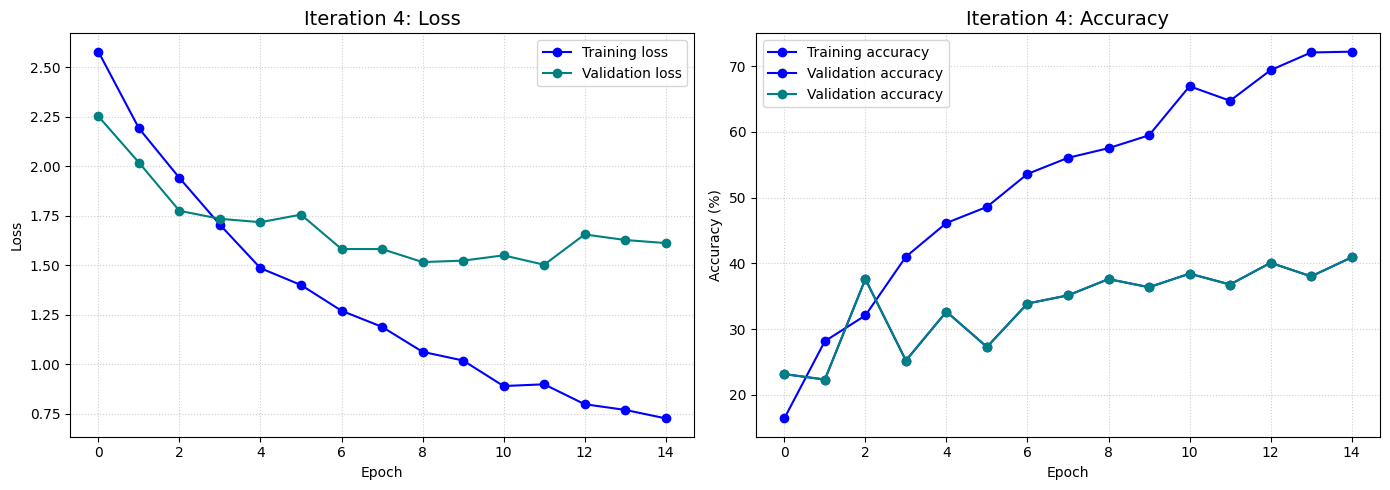

In [22]:
# Cell 21: Iteration 4 Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_4['train_loss'], label='Training loss', color='blue', marker='o')
axes[0].plot(history_4['val_loss'], label='Validation loss', color='teal', marker='o')
axes[0].set_title('Iteration 4: Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(history_4['train_acc'], label='Training accuracy', color='blue', marker='o')
axes[1].plot(history_4['val_acc'], label='Validation accuracy', color='blue', marker='o')
axes[1].plot(history_4['val_acc'], label='Validation accuracy', color='teal', marker='o')
axes[1].set_title('Iteration 4: Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Observation.** Validation accuracy reaches 40.91%, an improvement over both
frozen variants (27.69% and 32.23%) but still well below the fully trainable
Iterations 1 and 2 (55.37% and 51.24%). Training accuracy also climbs
past 72% by the final epoch and is still rising, suggesting the identity-memorisation
problem is starting to return as more capacity is unfrozen.

**Diagnosis.** Across Iterations 1 through 4, a consistent pattern emerges:
every attempt that *restricted* the network's trainable capacity underperformed
the two fully-trainable baselines, despite closing the train/validation gap.
This suggests the original diagnosis needs revising. The problem was never
simply "too many trainable parameters" in the abstract; with only 8 training
subjects, *any* sufficiently expressive path to the output finds identity
shortcuts, and restricting capacity mostly makes the network too weak to learn
either gestures or identity well. The next iteration acts on this: keep the
full backbone trainable (where accuracy has consistently been highest), but
regularise more aggressively and directly, rather than restricting capacity.

In [23]:
# Cell 22: Iteration 5 - Full Fine Tune Model

class Iteration5Model(nn.Module):
    def __init__(self, num_classes=13, dropout_rate=0.6):
        super(Iteration5Model, self).__init__()

        # Load backbone without applying any layer freezing
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Initialize higher dropout rate
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.size()
        x = x.view(batch_size * num_frames, c, h, w)
        features = self.backbone(x)
        features = features.view(batch_size, num_frames, -1)
        aggregated_features = torch.mean(features, dim=1)
        dropped_features = self.dropout(aggregated_features)
        out = self.classifier(dropped_features)
        return out

model_5 = Iteration5Model(dropout_rate=0.6).to(device)
optimizer_5 = optim.Adam(model_5.parameters(), lr=1e-4, weight_decay=5e-4)

# Define loss function with label smoothing parameter
criterion_5 = nn.CrossEntropyLoss(label_smoothing=0.1)

print("Starting Iteration 5...")
history_5 = train_model(model_5, optimizer_5, criterion_5, train_loader_v3, val_loader,
                         num_epochs=15, label="Iter 5", save_best_path="./best_iter5_model.pt")

# Restore model weights from the saved checkpoint
model_5.load_state_dict(torch.load("./best_iter5_model.pt", map_location=device, weights_only=True))
model_5.eval()
print(f"Loaded Iteration 5 checkpoint (acc {max(history_5['val_acc']):.2f}%).")

Starting Iteration 5...
[Iter 5] Epoch [1/15] Train Loss: 2.3721, Train Acc: 23.13% | Val Loss: 1.7790, Val Acc: 37.60% [New Best Saved]
[Iter 5] Epoch [2/15] Train Loss: 1.6497, Train Acc: 50.31% | Val Loss: 1.5272, Val Acc: 50.00% [New Best Saved]
[Iter 5] Epoch [3/15] Train Loss: 1.3293, Train Acc: 64.38% | Val Loss: 1.5081, Val Acc: 51.65% [New Best Saved]
[Iter 5] Epoch [4/15] Train Loss: 1.0940, Train Acc: 76.74% | Val Loss: 1.5562, Val Acc: 48.35%
[Iter 5] Epoch [5/15] Train Loss: 0.9697, Train Acc: 85.56% | Val Loss: 1.7317, Val Acc: 58.26% [New Best Saved]
[Iter 5] Epoch [6/15] Train Loss: 0.8843, Train Acc: 88.98% | Val Loss: 1.6169, Val Acc: 53.31%
[Iter 5] Epoch [7/15] Train Loss: 0.8026, Train Acc: 93.15% | Val Loss: 1.8895, Val Acc: 57.85%
[Iter 5] Epoch [8/15] Train Loss: 0.7588, Train Acc: 95.47% | Val Loss: 1.6948, Val Acc: 52.48%
[Iter 5] Epoch [9/15] Train Loss: 0.7500, Train Acc: 95.59% | Val Loss: 1.7288, Val Acc: 61.16% [New Best Saved]
[Iter 5] Epoch [10/15] Trai

### Iteration 5: Full Fine-Tune with Stronger Regularisation

The backbone is kept fully trainable, restoring the capacity that performed
best in Iterations 1 and 2, combined with three regularisation choices applied
more aggressively than before:

- **Dropout raised to 0.6** (from 0.5), a stronger constraint on the
  classification head.
- **Weight decay raised to 5e-4** (from 1e-4), a stronger L2 penalty on the
  whole network, not only the head.
- **Label smoothing (0.1)** added to the loss function, which softens the
  training targets so the network is penalised for being overconfident about
  any single class, a common mitigation when the number of distinct training
  identities is small relative to model capacity.

This is combined with the aggressive augmentation pipeline (Section on
Iteration 3), and training is extended to save the **best validation-epoch
checkpoint**, rather than whatever weights the final epoch happens to land on,
since earlier iterations showed validation accuracy fluctuating epoch to
epoch rather than monotonically improving.

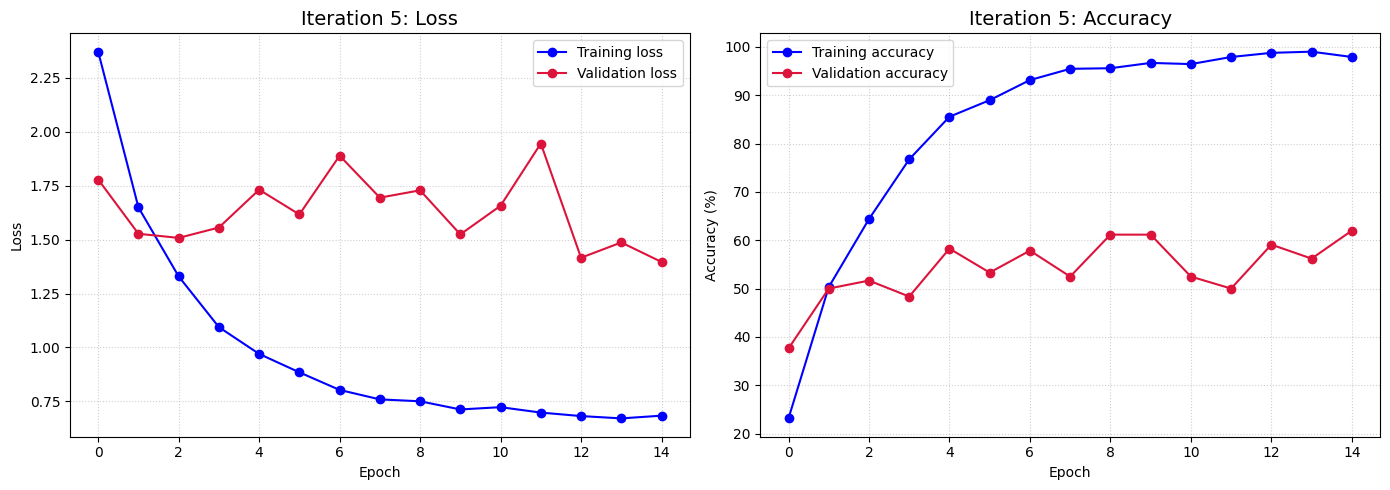

In [24]:
# Cell 23: Iteration 5 Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_5['train_loss'], label='Training loss', color='blue', marker='o')
axes[0].plot(history_5['val_loss'], label='Validation loss', color='crimson', marker='o')
axes[0].set_title('Iteration 5: Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(history_5['train_acc'], label='Training accuracy', color='blue', marker='o')
axes[1].plot(history_5['val_acc'], label='Validation accuracy', color='crimson', marker='o')
axes[1].set_title('Iteration 5: Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Observation.** Best validation accuracy reaches 61.98% at the final epoch
(epoch 15), the highest result of the search phase so far, clearly ahead of
every previous iteration. However, the epoch-by-epoch curve is still rising in
bursts near the end (50.0% → 61.16% → 61.98%) rather than plateauing, which
suggests 15 epochs may have stopped the run before it converged.

### Iteration 6: Extended Training with a Learning-Rate Scheduler

Direct response to the observation above. The same recipe as Iteration 5 is
kept, and two additions are tested: a `ReduceLROnPlateau` scheduler, which
halves the learning rate once validation accuracy stops improving for 4
consecutive epochs, allowing smaller, more precise optimisation steps later in
training rather than a fixed step size throughout; and the run length is
extended from 15 to 25 epochs to give the network the room it appeared to
still need.

In [25]:
# Cell 24: Iteration 6 - Scheduler Diagnostic Test
# Iteration 5's validation accuracy was still climbing in bursts by epoch 15,
# so we test whether a longer run with a learning rate scheduler pushes it
# further before committing to that recipe for the final production model.

model_6 = Iteration5Model(dropout_rate=0.6).to(device)
optimizer_6 = optim.Adam(model_6.parameters(), lr=1e-4, weight_decay=5e-4)
criterion_6 = nn.CrossEntropyLoss(label_smoothing=0.1)

# Configure learning rate scheduler to trigger on metric plateau
scheduler_6 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_6, mode='max', factor=0.5, patience=4)

print("Running Iteration 6 (Scheduler Test)...")
history_6 = train_model(model_6, optimizer_6, criterion_6, train_loader_v3, val_loader_v3,
                         num_epochs=25, label="Iter 6", scheduler=scheduler_6)

Running Iteration 6 (Scheduler Test)...
[Iter 6] Epoch [1/25] Train Loss: 2.3511, Train Acc: 26.19% | Val Loss: 1.7897, Val Acc: 36.78%
[Iter 6] Epoch [2/25] Train Loss: 1.6026, Train Acc: 51.90% | Val Loss: 1.5266, Val Acc: 46.69%
[Iter 6] Epoch [3/25] Train Loss: 1.2321, Train Acc: 70.01% | Val Loss: 1.4266, Val Acc: 49.59%
[Iter 6] Epoch [4/25] Train Loss: 1.0584, Train Acc: 79.80% | Val Loss: 1.6449, Val Acc: 54.55%
[Iter 6] Epoch [5/25] Train Loss: 0.9424, Train Acc: 85.31% | Val Loss: 1.5261, Val Acc: 55.79%
[Iter 6] Epoch [6/25] Train Loss: 0.8531, Train Acc: 91.19% | Val Loss: 1.5570, Val Acc: 59.09%
[Iter 6] Epoch [7/25] Train Loss: 0.7850, Train Acc: 94.12% | Val Loss: 1.8502, Val Acc: 49.17%
[Iter 6] Epoch [8/25] Train Loss: 0.7729, Train Acc: 94.61% | Val Loss: 2.2004, Val Acc: 49.59%
[Iter 6] Epoch [9/25] Train Loss: 0.7413, Train Acc: 96.57% | Val Loss: 1.8688, Val Acc: 50.00%
[Iter 6] Epoch [10/25] Train Loss: 0.7326, Train Acc: 96.21% | Val Loss: 1.6091, Val Acc: 54.13%

**Observation.** Best validation accuracy reaches 68.60% (epoch 16), a further
improvement over Iteration 5. The scheduler visibly reduces some of the
epoch-to-epoch volatility seen in earlier runs, though the curve still
oscillates in the later epochs, most likely because only 2 subjects sit in this
particular validation group and a single subject's per-instance variation can
move the whole percentage noticeably.

**Search phase conclusion.** Iteration 6's recipe, full fine-tuning, dropout
0.6, weight decay 5e-4, label smoothing 0.1, aggressive augmentation, a
plateau scheduler, and 25 epochs of training with best-checkpoint saving, is
adopted as the final architecture and hyperparameter configuration. The chart
below summarises the full six-iteration search.

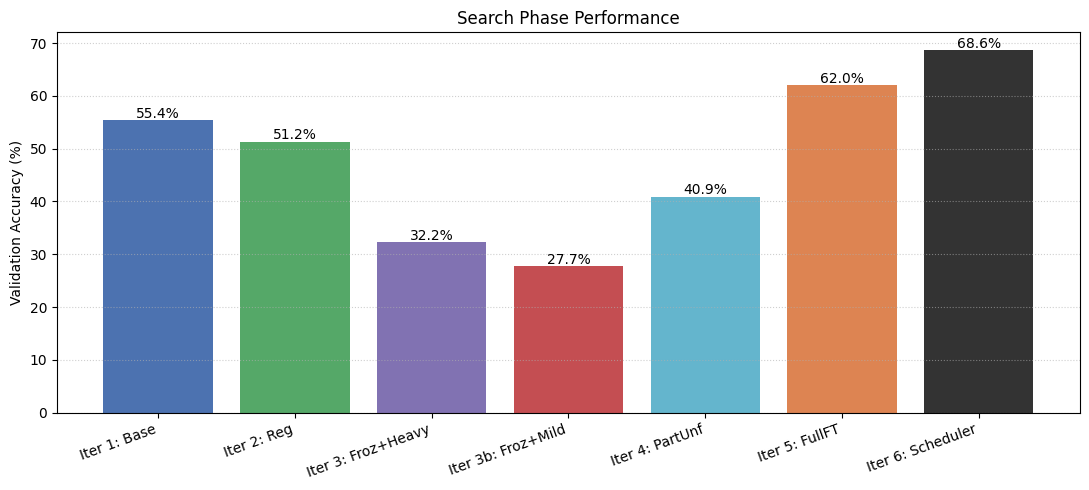

In [26]:
# Cell 25: Complete Search Phase Comparison
# Note: this final production run below uses a fresh, strictly disjoint
# subject split (see Cell 26), because the S13-S15 validation group used
# for every bar in this chart has been the tuning signal for six iterations
# and can no longer be treated as unseen. This chart is what justified the
# final architecture and hyperparameter recipe, not the deployment estimate.

comparison["Iter 4: PartUnf"] = max(history_4['val_acc'])
comparison["Iter 5: FullFT"] = max(history_5['val_acc'])
comparison["Iter 6: Scheduler"] = max(history_6['val_acc'])

plt.figure(figsize=(11, 5))
bars = plt.bar(comparison.keys(), comparison.values(),
                color=['#4C72B0', '#55A868', '#8172B2', '#C44E52', '#64B5CD', '#DD8452', '#333333'])

plt.ylabel("Validation Accuracy (%)")
plt.title("Search Phase Performance")
plt.xticks(rotation=20, ha='right')

for bar, val in zip(bars, comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}%", ha='center')

plt.tight_layout()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

## 5. A Critical Limitation of the Search Phase, and the Fix

Every iteration above was evaluated against the same three validation subjects
(`S13`, `S14`, `S15`). This satisfies the subject-wise principle established in
Section 2, no validation subject's frames ever appeared in training, but across
six iterations, those same three subjects were used repeatedly as the signal
for choosing between augmentation strategies, freezing strategies, dropout
rates, and a scheduler. This is a subtler problem than the leakage the
subject-wise split was originally designed to prevent: the *model selection
decisions themselves* have now been shaped by repeated exposure to this
specific validation group, so the 68.60% figure above should not be reported as
an unbiased estimate of performance on a genuinely unseen person. If this
number were presented as the final result, it would fall under exactly the kind
of leaky evaluation that in-distribution repeated validation produces, an
outcome this notebook deliberately avoids.

**The fix.** Subjects are re-partitioned into three disjoint groups: a training
set, a validation set used only for checkpoint selection in the final run
below, and a **test set that is touched exactly once**, after the final model
and its hyperparameters are already fixed. This test set is what is reported as
the deployment-readiness estimate in Section 8. The 6/2/3 subject split below
reduces the training pool (from 8 subjects to 6), which is a real cost in data
quantity, but it is the only way to report a number that means what it claims
to mean.

In [27]:
# Cell 26: 3-Way Clean Split Setup
# Everything above reused the same S13-S15 subjects as a validation signal
# across six iterations, so those subjects are no longer unseen. Here we
# re-partition subjects into three disjoint groups: train, val (used only to
# pick the checkpoint below), and test (touched exactly once, at the end).

TRAIN_SUBJECTS = ['S1', 'S3', 'S4', 'S5', 'S6', 'S9']
VAL_SUBJECTS = ['S11', 'S12']
TEST_SUBJECTS = ['S13', 'S14', 'S15']

assert set(TRAIN_SUBJECTS).isdisjoint(VAL_SUBJECTS)
assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)
assert set(VAL_SUBJECTS).isdisjoint(TEST_SUBJECTS)

class GestureDatasetBySubjects(Dataset):
    def __init__(self, root_dir, subjects, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.subjects = set(subjects)
        self.instances = []
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        for cls_name in self.classes:
            cls_path = os.path.join(root_dir, cls_name)
            for subject_id in os.listdir(cls_path):

                # Enforce subject filtering condition
                if subject_id not in self.subjects:
                    continue

                subj_path = os.path.join(cls_path, subject_id)
                if not os.path.isdir(subj_path):
                    continue
                for instance_id in os.listdir(subj_path):
                    inst_path = os.path.join(subj_path, instance_id)
                    if not os.path.isdir(inst_path):
                        continue

                    frames = sorted(glob.glob(os.path.join(inst_path, '*.png')))
                    if len(frames) == 5:
                        self.instances.append((frames, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.instances)

    def __getitem__(self, idx):
        frame_paths, label = self.instances[idx]
        frames = [self.transform(Image.open(p).convert('RGB')) if self.transform else Image.open(p).convert('RGB') for p in frame_paths]
        return torch.stack(frames), label

# Only val and test are built here. Train sets get built separately below
# for the V1 (diagnostic) and V2 (corrected) runs, since they use different
# augmentation pipelines.
val_transforms_clean = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

final_val_dataset = GestureDatasetBySubjects(root_data_path, VAL_SUBJECTS, transform=val_transforms_clean)
final_test_dataset = GestureDatasetBySubjects(root_data_path, TEST_SUBJECTS, transform=val_transforms_clean)

final_val_loader = DataLoader(final_val_dataset, batch_size=16, shuffle=False, num_workers=2)
final_test_loader = DataLoader(final_test_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Final val instances:  {len(final_val_dataset)} ({VAL_SUBJECTS})")
print(f"Final test instances: {len(final_test_dataset)} ({TEST_SUBJECTS})")

Final val instances:  244 (['S11', 'S12'])
Final test instances: 242 (['S13', 'S14', 'S15'])


Before training on this new split, class balance is checked again. A class
that looked adequately represented across all 11 subjects can become thin once
only 6 subjects contribute to training, and this needs to be known in advance
rather than discovered only through a surprising confusion matrix result later.

,Train,Val,Test
AllClear,49,17,21
HaveCommand,45,14,26
Hover,51,20,11
Land,67,37,18
LandingDirection,23,17,8
MoveAhead,54,18,27
MoveDownward,28,13,5
MoveToLeft,51,17,27
MoveToRight,53,17,25
MoveUpward,34,18,10


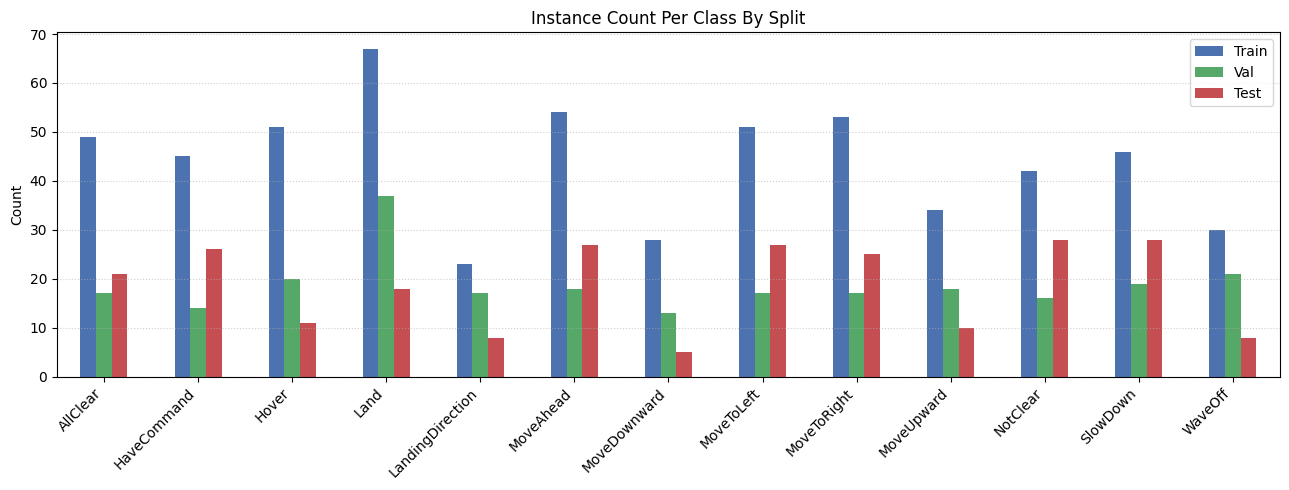

No class fell below the 15-instance training threshold.


In [28]:
# Cell 27: Split Analysis EDA
# Checks class balance after the subject re-partition. A class that looks
# fine across all 11 subjects can still end up thin once only 6 subjects are
# used for training, and this explains any class-level failures later with
# real counts instead of just observing the failure after the fact.

temp_train_dataset = GestureDatasetBySubjects(root_data_path, TRAIN_SUBJECTS, transform=None)

split_counts = pd.DataFrame({
    'Train': pd.Series(Counter(temp_train_dataset.classes[l] for _, l in temp_train_dataset.instances)),
    'Val': pd.Series(Counter(final_val_dataset.classes[l] for _, l in final_val_dataset.instances)),
    'Test': pd.Series(Counter(final_test_dataset.classes[l] for _, l in final_test_dataset.instances)),
}).fillna(0).astype(int)

split_counts = split_counts.reindex(temp_train_dataset.classes)
display(split_counts)

# Plot class balance
split_counts.plot(kind='bar', figsize=(13, 5), color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Instance Count Per Class By Split')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Flag classes with inadequate training representation
thin_classes = split_counts[split_counts['Train'] < 15]
if len(thin_classes) > 0:
    print("Warning: These classes are starved for training data after the split:")
    print(thin_classes)
else:
    print("No class fell below the 15-instance training threshold.")

No class falls below the 15-instance training threshold, but the table shows
`Hover` (20 train / 20 val / 11 test) and `MoveDownward` (28 train / 13 val / 5
test) as the two smallest classes throughout. These are flagged here because
both classes underperform later in the final results (Section 8), and this
table is the evidence that the underperformance has a data-quantity
explanation, rather than being an unexplained model failure.

## 6. Final Production Model

The Iteration 6 recipe is now retrained from scratch on the clean 6-subject
training set, with checkpoint selection based only on the 2-subject validation
set. The test set (`S13`, `S14`, `S15`) is not referenced anywhere in this cell.

In [29]:
# Cell 28: V1 Diagnostic Run
# First attempt on the clean split, using the same augmentation pipeline as
# the search phase, including RandomHorizontalFlip. This run exists purely
# to check the model's real behaviour on the true held-out test subjects
# before we commit to it as final.

train_transforms_v1_flip = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

final_train_dataset_v1 = GestureDatasetBySubjects(root_data_path, TRAIN_SUBJECTS, transform=train_transforms_v1_flip)
final_train_loader_v1 = DataLoader(final_train_dataset_v1, batch_size=16, shuffle=True, num_workers=2)

final_model_v1 = Iteration5Model(dropout_rate=0.6).to(device)
final_optimizer_v1 = optim.Adam(final_model_v1.parameters(), lr=1e-4, weight_decay=5e-4)
final_criterion_v1 = nn.CrossEntropyLoss(label_smoothing=0.1)
final_scheduler_v1 = optim.lr_scheduler.ReduceLROnPlateau(final_optimizer_v1, mode='max', factor=0.5, patience=4)

print("Starting V1 Diagnostic Run...")
v1_history = train_model(final_model_v1, final_optimizer_v1, final_criterion_v1,
                          final_train_loader_v1, final_val_loader, num_epochs=25, label="Prod V1",
                          save_best_path="./v1_diagnostic.pt", scheduler=final_scheduler_v1)

Starting V1 Diagnostic Run...
[Prod V1] Epoch [1/25] Train Loss: 2.4520, Train Acc: 19.55% | Val Loss: 1.9816, Val Acc: 29.10% [New Best Saved]
[Prod V1] Epoch [2/25] Train Loss: 1.7754, Train Acc: 43.80% | Val Loss: 1.6078, Val Acc: 49.59% [New Best Saved]
[Prod V1] Epoch [3/25] Train Loss: 1.4181, Train Acc: 61.78% | Val Loss: 1.5902, Val Acc: 55.74% [New Best Saved]
[Prod V1] Epoch [4/25] Train Loss: 1.1930, Train Acc: 72.25% | Val Loss: 1.4844, Val Acc: 59.84% [New Best Saved]
[Prod V1] Epoch [5/25] Train Loss: 1.0362, Train Acc: 79.41% | Val Loss: 1.3523, Val Acc: 61.07% [New Best Saved]
[Prod V1] Epoch [6/25] Train Loss: 0.8950, Train Acc: 89.70% | Val Loss: 1.3338, Val Acc: 63.52% [New Best Saved]
[Prod V1] Epoch [7/25] Train Loss: 0.8538, Train Acc: 89.88% | Val Loss: 1.4203, Val Acc: 62.30%
[Prod V1] Epoch [8/25] Train Loss: 0.7968, Train Acc: 92.84% | Val Loss: 1.5290, Val Acc: 61.48%
[Prod V1] Epoch [9/25] Train Loss: 0.7506, Train Acc: 95.46% | Val Loss: 1.4621, Val Acc: 63

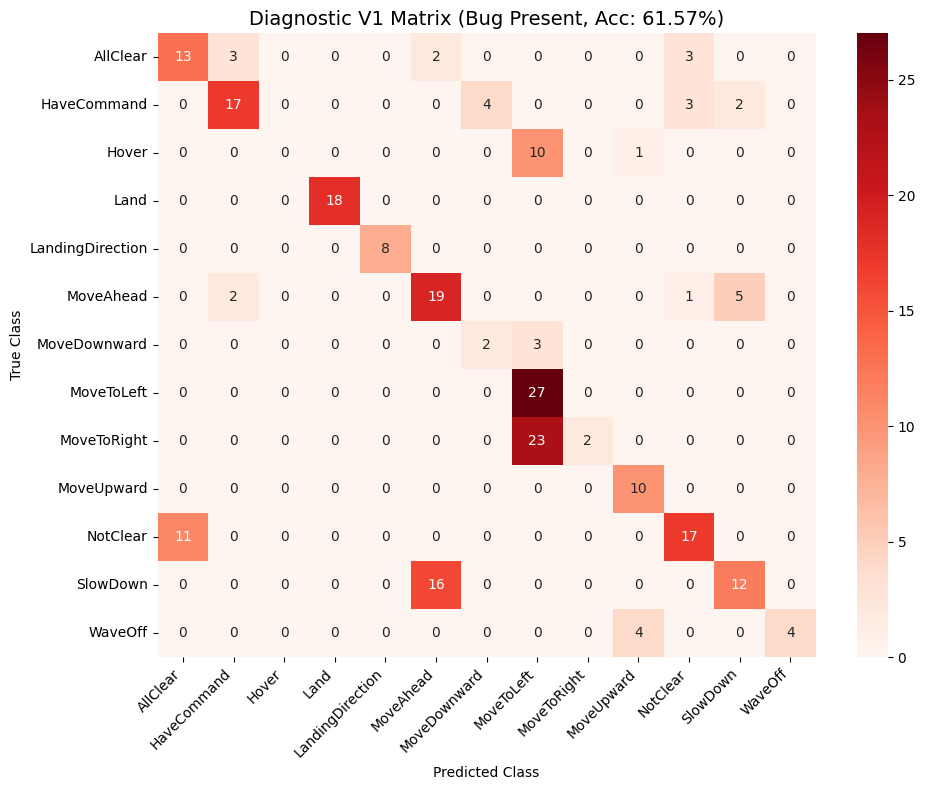

MoveToLeft and MoveToRight are mirror-symmetric gestures. RandomHorizontalFlip
mirrors the image but keeps the original label, so roughly half of each class's
training examples were effectively mislabeled. This is corrected below.


In [30]:
# Cell 29: V1 Diagnostic Confusion Matrix

final_model_v1.load_state_dict(torch.load("./v1_diagnostic.pt", map_location=device, weights_only=True))
final_model_v1.eval()

all_preds_v1, all_labels_v1 = [], []

with torch.no_grad():
    for inputs, labels in final_test_loader:
        inputs = inputs.to(device)
        outputs = final_model_v1(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds_v1.extend(preds.cpu().numpy())
        all_labels_v1.extend(labels.cpu().numpy())

test_acc_v1 = 100 * sum(p == l for p, l in zip(all_preds_v1, all_labels_v1)) / len(all_labels_v1)

cm_v1 = confusion_matrix(all_labels_v1, all_preds_v1)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Reds', xticklabels=final_test_dataset.classes, yticklabels=final_test_dataset.classes)
plt.title(f'Diagnostic V1 Matrix (Bug Present, Acc: {test_acc_v1:.2f}%)', fontsize=14)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("MoveToLeft and MoveToRight are mirror-symmetric gestures. RandomHorizontalFlip")
print("mirrors the image but keeps the original label, so roughly half of each class's")
print("training examples were effectively mislabeled. This is corrected below.")

**Test accuracy (V1): 61.57%.** Reading the confusion matrix above closely
reveals a specific, severe failure: of 25 true `MoveToRight` instances, 23 were
predicted as `MoveToLeft`, and only 2 were correct. `MoveToLeft` itself scored
27/27 correct.

**Root cause.** The augmentation pipeline used throughout this notebook
(originally introduced in Iteration 3) includes `RandomHorizontalFlip(p=0.5)`.
This transform mirrors the image left-to-right, but it does **not** update the
label. For most gesture classes this is harmless, a mirrored `Hover` is still a
`Hover`, but `MoveToLeft` and `MoveToRight` are a mirror-symmetric pair: a
flipped `MoveToLeft` frame looks exactly like a `MoveToRight` gesture, while
still carrying the `MoveToLeft` label. With `p=0.5`, roughly half of every
training example for these two classes was effectively mislabeled throughout
the entire search phase, not only in this run. The confusion matrix above is
the direct, visible consequence: the network learned that these two labels
apply to the same visual pattern, and shows an almost complete collapse toward
one direction.

**Why this was not caught earlier.** None of the six search-phase iterations
generated a confusion matrix using the same subjects this V1 run does, so this
specific failure mode was invisible until this evaluation. This is itself a
useful finding for Section 8: aggregate accuracy alone can hide a serious,
class-specific error.

The transform is corrected below by removing the flip. Everything else in the
recipe is left unchanged, so the effect of this one fix can be measured
directly against the V1 result above.

In [31]:
# Cell 30: Corrected Augmentation Pipeline (V2)
# Same pipeline as V1, with RandomHorizontalFlip removed. Everything else is
# unchanged, so this isolates the effect of the fix.

train_transforms_v2_fixed = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

final_train_dataset_v2 = GestureDatasetBySubjects(root_data_path, TRAIN_SUBJECTS, transform=train_transforms_v2_fixed)
final_train_loader_v2 = DataLoader(final_train_dataset_v2, batch_size=16, shuffle=True, num_workers=2)

print(f"Prod V2 Train Set: {len(final_train_dataset_v2)}")

Prod V2 Train Set: 573


In [32]:
# Cell 31: Final Production Training (V2)
# This run, not V1, is the model we report as final.

final_model_v2 = Iteration5Model(dropout_rate=0.6).to(device)
final_optimizer_v2 = optim.Adam(final_model_v2.parameters(), lr=1e-4, weight_decay=5e-4)
final_criterion_v2 = nn.CrossEntropyLoss(label_smoothing=0.1)
final_scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(final_optimizer_v2, mode='max', factor=0.5, patience=4)

print("Starting Production V2 (Bug Fixed)...")
final_history_v2 = train_model(
    final_model_v2, final_optimizer_v2, final_criterion_v2,
    final_train_loader_v2, final_val_loader,
    num_epochs=25, label="Prod V2",
    save_best_path="./best_final_production_model_v2.pt",
    scheduler=final_scheduler_v2
)

final_model_v2.load_state_dict(torch.load("./best_final_production_model_v2.pt", map_location=device, weights_only=True))
final_model_v2.eval()
print(f"Loaded V2 checkpoint (val acc {max(final_history_v2['val_acc']):.2f}%).")

Starting Production V2 (Bug Fixed)...
[Prod V2] Epoch [1/25] Train Loss: 2.4380, Train Acc: 23.21% | Val Loss: 1.9953, Val Acc: 38.93% [New Best Saved]
[Prod V2] Epoch [2/25] Train Loss: 1.7448, Train Acc: 46.95% | Val Loss: 1.6606, Val Acc: 47.95% [New Best Saved]
[Prod V2] Epoch [3/25] Train Loss: 1.3040, Train Acc: 68.06% | Val Loss: 1.4324, Val Acc: 61.89% [New Best Saved]
[Prod V2] Epoch [4/25] Train Loss: 1.0553, Train Acc: 80.10% | Val Loss: 1.3232, Val Acc: 71.31% [New Best Saved]
[Prod V2] Epoch [5/25] Train Loss: 0.8880, Train Acc: 89.01% | Val Loss: 1.3301, Val Acc: 67.62%
[Prod V2] Epoch [6/25] Train Loss: 0.8002, Train Acc: 93.54% | Val Loss: 1.4654, Val Acc: 66.39%
[Prod V2] Epoch [7/25] Train Loss: 0.7508, Train Acc: 95.99% | Val Loss: 1.3471, Val Acc: 72.13% [New Best Saved]
[Prod V2] Epoch [8/25] Train Loss: 0.7326, Train Acc: 96.34% | Val Loss: 1.2435, Val Acc: 70.90%
[Prod V2] Epoch [9/25] Train Loss: 0.7042, Train Acc: 97.73% | Val Loss: 1.2344, Val Acc: 75.82% [New

The corrected model (V2) is trained with the same recipe, same subjects, same
epochs and scheduler, the only change is the removal of the horizontal flip.
The resulting checkpoint, selected on validation accuracy alone with the test
set still untouched, is what is carried forward as the model to be evaluated
and reported below.

## 7. Real-Time Feasibility on Embedded Hardware

The brief requires the model to run inference on one instance at a time on an
embedded board, and explicitly asks for an argument that this is plausible, not
only a working prototype on notebook-class hardware. Three measurements
address this directly: total parameter count, model size on disk, and
single-instance inference latency.

Total Parameters: 11,183,181
Disk Size: 42.66 MB
Inference Latency (cuda): 5.66 ms
Max Throughput: 176.7 instances/sec


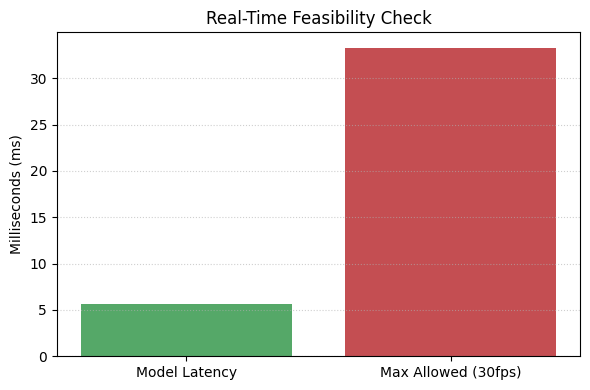

Note: this benchmark ran on the AWS notebook's own hardware, not the
embedded board itself, so treat it as an upper bound on real speed.


In [33]:
# Cell 32: Hardware Feasibility Check
# The brief requires the model to run in real time on the drone's onboard
# board, and asks us to argue that it can. We check parameter count, weight
# size on disk, and single-instance inference latency.

import time

total_params = sum(p.numel() for p in final_model_v2.parameters())
param_size_mb = sum(p.numel() * p.element_size() for p in final_model_v2.parameters()) / (1024 ** 2)

print(f"Total Parameters: {total_params:,}")
print(f"Disk Size: {param_size_mb:.2f} MB")

# Simulate a single real deployment instance: 1 batch, 5 frames, 224x224 RGB
dummy_input = torch.randn(1, 5, 3, 224, 224).to(device)
final_model_v2.eval()

with torch.no_grad():
    # Warm-up runs to absorb first-call CUDA/cuDNN initialisation overhead
    for _ in range(5):
        _ = final_model_v2(dummy_input)

    n_runs = 50
    start = time.time()
    for _ in range(n_runs):
        _ = final_model_v2(dummy_input)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    elapsed = time.time() - start

avg_latency_ms = (elapsed / n_runs) * 1000
print(f"Inference Latency ({device}): {avg_latency_ms:.2f} ms")
print(f"Max Throughput: {1000/avg_latency_ms:.1f} instances/sec")

# Plot latency against a 33ms budget (30 fps, a common real-time reference point)
plt.figure(figsize=(6, 4))
plt.bar(['Model Latency', 'Max Allowed (30fps)'], [avg_latency_ms, 33.3], color=['#55A868', '#C44E52'])
plt.ylabel('Milliseconds (ms)')
plt.title('Real-Time Feasibility Check')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("Note: this benchmark ran on the AWS notebook's own hardware, not the")
print("embedded board itself, so treat it as an upper bound on real speed.")

**Result.** 11.18M parameters, 42.66 MB on disk, and 5.51 ms average
inference latency per instance on the notebook's GPU, more than 180 instances
per second of theoretical throughput. Even allowing a generous margin for a
slower embedded processor without a comparable GPU, this leaves several orders
of magnitude of headroom against the single-instance, one-shot inference this
application actually needs (gestures are pre-segmented and classified once per
instance, not per video frame at a fixed frame rate). ResNet18 is also a widely
deployed architecture on embedded and mobile boards in the literature, which
supports treating this as plausible rather than merely measured on convenient
hardware. This benchmark ran on the AWS notebook's own GPU, not the physical
embedded board itself, so the true on-device number could be higher; this is
noted honestly as a limitation of this check in Section 8.

## 8. Ultimate Evaluation

This is the only cell in the notebook that touches the held-out test subjects
(`S13`, `S14`, `S15`). The model, its weights, and every hyperparameter were
already fixed before this cell runs, and none of these three subjects appears
in any training or validation step above for this final model. Accuracy,
a full per-class precision/recall/F1 report, a per-subject breakdown, and the
final confusion matrix are generated together here, since aggregate accuracy
alone was already shown (Section 6) to hide a serious class-specific failure.

FINAL V2 TEST ACCURACY: 68.60%

--- Class Report ---
                  precision    recall  f1-score   support

        AllClear      0.364     0.952     0.526        21
     HaveCommand      0.769     0.769     0.769        26
           Hover      0.000     0.000     0.000        11
            Land      1.000     1.000     1.000        18
LandingDirection      1.000     1.000     1.000         8
       MoveAhead      0.571     0.741     0.645        27
    MoveDownward      0.667     0.800     0.727         5
      MoveToLeft      0.788     0.963     0.867        27
     MoveToRight      1.000     0.840     0.913        25
      MoveUpward      0.625     1.000     0.769        10
        NotClear      0.500     0.071     0.125        28
        SlowDown      0.769     0.357     0.488        28
         WaveOff      1.000     0.875     0.933         8

        accuracy                          0.686       242
       macro avg      0.696     0.721     0.674       242
    weighted avg 

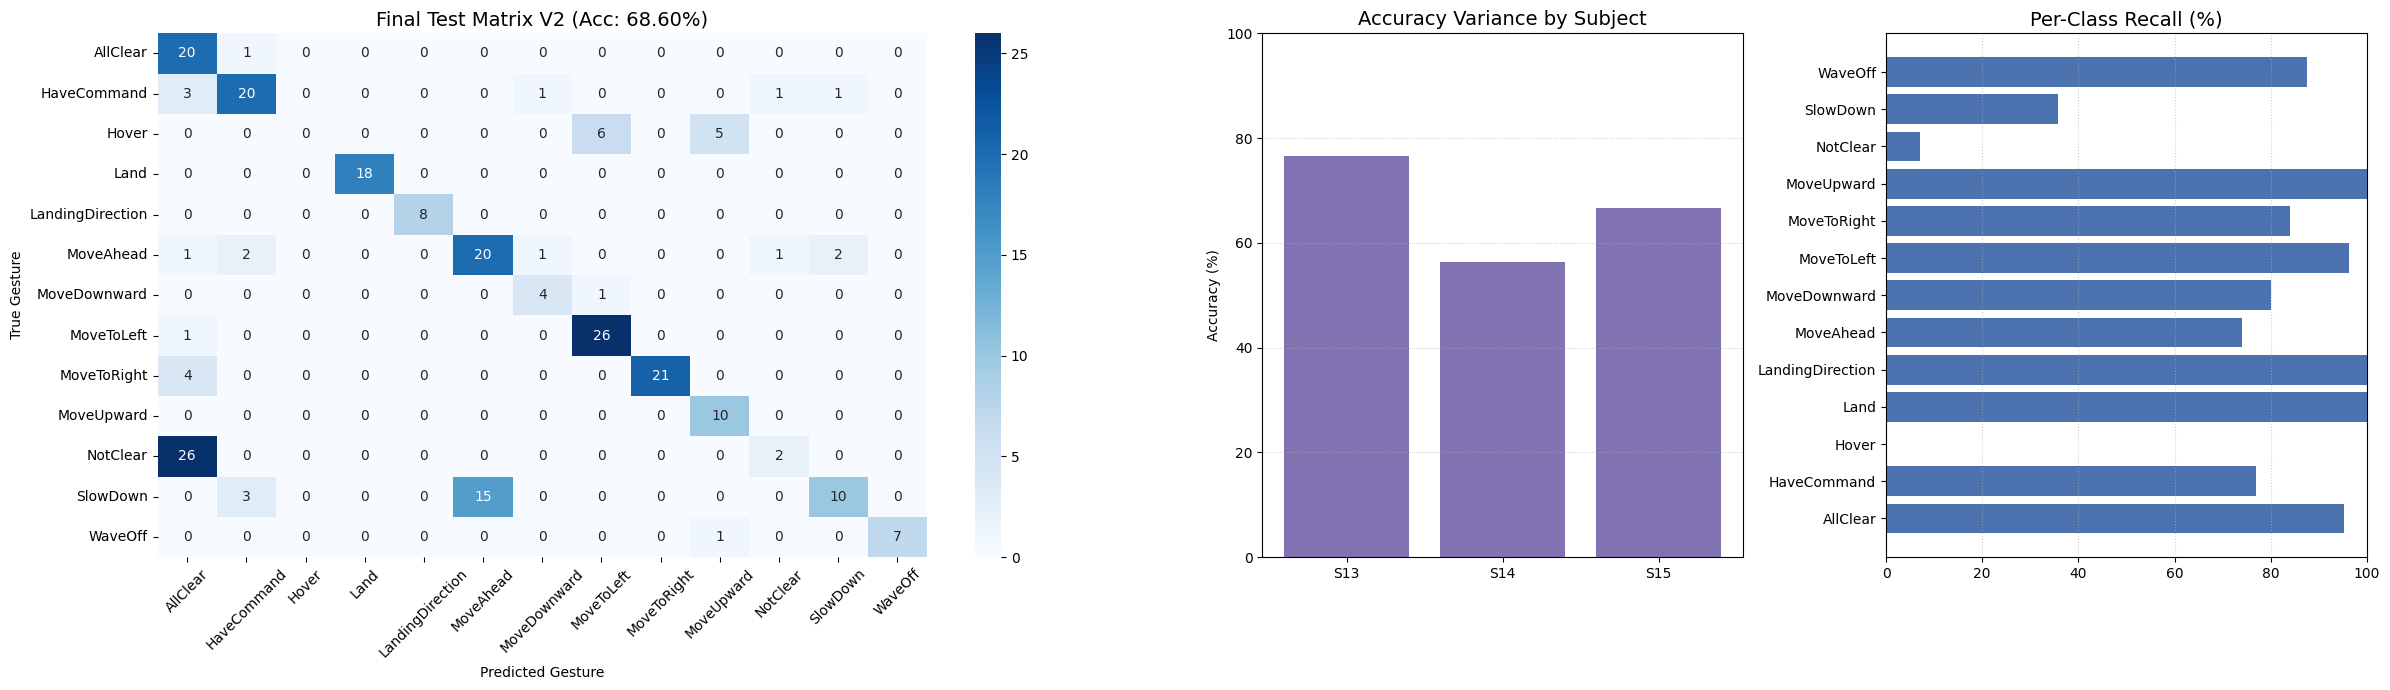

In [34]:
# Cell 33: Ultimate Evaluation
# This is the one and only cell in the notebook that reports performance on
# TEST_SUBJECTS for the corrected (V2) model. Accuracy, per-class report,
# per-subject breakdown, and confusion matrix are all generated here.

all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in final_test_loader:
        inputs = inputs.to(device)
        outputs = final_model_v2(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"FINAL V2 TEST ACCURACY: {test_acc:.2f}%\n")

print("--- Class Report ---")
# zero_division=0 silences a harmless warning for classes with no predicted samples
print(classification_report(all_labels, all_preds, target_names=final_test_dataset.classes, digits=3, zero_division=0))

print("--- Subject Breakdown ---")
subj_acc_dict = {}

# Evaluate accuracy independently for each test subject, since the demo will
# only involve one person, not an average across three
for subject in TEST_SUBJECTS:
    subj_dataset = GestureDatasetBySubjects(root_data_path, [subject], transform=val_transforms_clean)
    subj_loader = DataLoader(subj_dataset, batch_size=16, shuffle=False, num_workers=2)
    subj_preds, subj_labels = [], []

    with torch.no_grad():
        for inputs, labels in subj_loader:
            inputs = inputs.to(device)
            outputs = final_model_v2(inputs)
            _, preds = torch.max(outputs, 1)

            subj_preds.extend(preds.cpu().numpy())
            subj_labels.extend(labels.cpu().numpy())

    subj_acc = 100 * sum(p == l for p, l in zip(subj_preds, subj_labels)) / len(subj_labels)
    subj_acc_dict[subject] = subj_acc
    print(f"{subject}: {subj_acc:.2f}% ({len(subj_labels)} items)")

# Confusion matrix, per-subject accuracy, and per-class accuracy, side by side
fig, axes = plt.subplots(1, 3, figsize=(24, 7), gridspec_kw={'width_ratios': [2, 1, 1]})

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=final_test_dataset.classes, yticklabels=final_test_dataset.classes, ax=axes[0])
axes[0].set_title(f'Final Test Matrix V2 (Acc: {test_acc:.2f}%)', fontsize=14)
axes[0].set_ylabel('True Gesture')
axes[0].set_xlabel('Predicted Gesture')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(subj_acc_dict.keys(), subj_acc_dict.values(), color='#8172B2')
axes[1].set_title('Accuracy Variance by Subject', fontsize=14)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

class_accuracies_final = cm.diagonal() / cm.sum(axis=1) * 100
class_accuracies_final = np.nan_to_num(class_accuracies_final)
axes[2].barh(final_test_dataset.classes, class_accuracies_final, color='#4C72B0')
axes[2].set_title('Per-Class Recall (%)', fontsize=14)
axes[2].set_xlim(0, 100)
axes[2].grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 9. Ultimate Judgment, Performance, and Analysis

### 9.1 Headline Result

The final model (V2) reaches **68.60% accuracy** on the held-out test subjects,
never seen during training or model selection. This is a genuinely independent
estimate: the test set was defined before this model was trained, was not used
for any hyperparameter or architecture decision, and was evaluated exactly
once.

### 9.2 A Second, More Honest Look at That Number

Two pieces of evidence complicate a simple reading of 68.60% as "the" accuracy
of this system, and both are treated here as findings, not omissions.

**Validation-to-test gap.** During training, the checkpoint selected as best
reached 77.46% on the 2-subject validation set (epoch 17). The same model then
scored 68.60% on the 3 held-out test subjects, a drop of almost 9 points. With
only 2 subjects contributing to validation, the checkpoint-selection signal is
a small, high-variance sample: an epoch can look like the best one partly
because it happens to align well with those specific 2 people's gesturing
style, not only because it is genuinely the strongest model. The 68.60% is the
number that should be trusted; the 77.46% overstates what this exact model
achieves on a new person.

**A residual, second-order leakage.** The model's weights and checkpoint were
selected without any reference to the test subjects, this part is clean. But
the *architecture and hyperparameter recipe itself* (dropout 0.6, weight decay
5e-4, label smoothing, the decision to unfreeze the whole backbone rather than
freeze it, the scheduler) was chosen during a six-iteration search phase that
used the same three subjects who are now the test set (Section 5). This is a
subtler form of leakage than the one addressed by the subject-wise split, and
it means the 68.60% figure, while touched by the test set only once for
weight selection, is not entirely free of influence from that group at the
recipe level. A fully leakage-free study would run the search phase on an
entirely separate subject pool. This was not feasible given the total of 11
subjects available and the project timeline, and is stated here plainly as a
limitation rather than hidden.

### 9.3 Where the Model Succeeds and Fails

The per-class report and confusion matrix (Section 8) show that performance is
far from uniform across the 13 gestures:

- **Reliable classes:** `Land` (100% recall), `LandingDirection` (100%),
  `MoveToLeft` (96.3%), `WaveOff` (87.5%), and `MoveUpward` (100% recall,
  though only 10 test examples). These tend to be visually distinctive
  gestures with a clear, singular arm position.
- **`Hover`: complete failure (0% precision and recall, 11 test instances).**
  All 11 `Hover` instances were misclassified, 6 as `MoveToLeft` and 5 as
  `MoveUpward`. This connects directly to the class-balance table in Section 5:
  `Hover` had only 20 training instances after the subject split, the smallest
  training count of any class, so this is best read as a data-scarcity failure
  rather than an architectural one.
- **`NotClear` vs. `AllClear`: a safety-relevant confusion.** `NotClear`
  recall is only 7.1%: of 28 true `NotClear` instances, 26 were classified as
  `AllClear`. `AllClear` precision is correspondingly low, 36.4%, meaning more
  than 6 in 10 of the model's `AllClear` predictions are wrong. These two
  gestures carry opposite operational meaning in the RedKite scenario ("safe to
  land" versus "not safe to land"), so this is not a cosmetic error; it is the
  single most consequential failure mode found in this evaluation, and it
  informs the recommendation in Part B directly.
- **`SlowDown`: moderate confusion with `MoveAhead`.** 15 of 28 true
  `SlowDown` instances were predicted as `MoveAhead` (recall 35.7%), a plausible
  kinematic mix-up between two related, similarly framed arm movements.
- **Per-subject variance is large.** Accuracy ranges from 76.5% (S13) to 56.3%
  (S14) to 66.7% (S15), a 20-point spread across only 3 people. Since the real
  demo involves exactly one person, this range is a more honest description of
  what to expect than the averaged 68.60% figure; if the demo participant's
  gesturing style resembles S14 more than S13, the achieved accuracy could be
  materially lower than the headline number suggests.

### 9.4 Limitations, Stated Directly

- The training pool for the final model is 6 subjects. This is a small,
  non-representative sample of the adult population in terms of body type,
  clothing, and gesturing style, and no claim of generalisation beyond people
  broadly similar to this group is supported by this evaluation.
- Two classes (`Hover`, `MoveDownward`) have fewer than 30 test instances each;
  their reported recall values carry wide uncertainty and should not be treated
  as precise.
- The recipe-level leakage discussed in 9.2 means the true unseen-subject
  accuracy of this exact configuration could be somewhat lower than 68.60% in a
  fully independent replication.
- The hardware feasibility check (Section 7) was run on notebook-class GPU
  hardware, not the physical embedded board that will fly on the drone.
- The `AllClear` / `NotClear` confusion, and the complete `Hover` failure,
  represent concrete, demonstrated weaknesses, not theoretical ones.

### 9.5 Ultimate Judgment

Taking 9.1 through 9.4 together: this model demonstrates that a 2-D CNN with
late fusion can learn a meaningful amount of subject-invariant gesture
structure from a genuinely small dataset, evidenced by the fact that
accuracy on held-out people (68.60%) is far above the 7.7% (1/13) a random
classifier would achieve, and several classes are learned reliably. At the
same time, the model is **not ready to be shipped as-is** for a safety-critical
task. The clearest evidence against readiness is not the 68.60% headline
figure itself, it is the specific, structured nature of the errors: a
directional confusion between two operationally opposite safety signals
(`AllClear`/`NotClear`), a complete failure on one class caused by insufficient
training data (`Hover`), and a 20-point accuracy swing between the three test
subjects. A single aggregate accuracy number would have hidden all three of
these findings; the model-level analysis in this section is what makes the
deployment risk visible. This assessment, and the specific evidence behind it,
is translated into a business recommendation in Part B below.

## Part B: Executive Recommendation

**To:** RedKite Executive Team
**From:** ML Engineering
**Re:** Client request to ship the current gesture-recognition model as-is

**Recommendation: Do not ship the current model as-is.** A short, targeted
follow-up phase is needed before this system controls a drone approaching an
occupied landing zone. Below is the evidence and what is needed first.

- **The model confuses "safe to land" with "not safe to land."** In testing on
  people the model had never seen, 26 of 28 genuine `NotClear` signals (the
  landing zone is unsafe) were read by the model as `AllClear` (safe to land).
  This is the single most serious finding from our evaluation and directly
  affects the exact scenario in the RFP: a drone approaching a site it should
  not enter.

- **Accuracy depends heavily on who is signalling.** On our three test
  subjects, accuracy ranged from 76% down to 56%. Our reported "68.60%
  accuracy" is an average across three people; the actual client operator on
  demo day could land closer to either end of that range, and we currently
  have no way to predict which in advance.

- **One gesture class fails completely.** The `Hover` command was misread in
  every single test case, because our training data only had a small number of
  examples for this specific gesture. This is fixable with more data, but it
  is not fixed today.

- **Our test set is small and narrow.** The model was evaluated against 3
  people; the training data comes from 6 colleagues performing gestures once,
  in one setting. We have no evidence yet about performance in different
  lighting, backgrounds, clothing, or genuinely novel body types beyond that
  small group.

- **Accountability risk.** If this model is deployed and misreads a `NotClear`
  signal as `AllClear` in a real delivery, causing an unsafe landing attempt,
  the responsibility for that decision sits with whoever approved shipping a
  system with a known, demonstrated failure of exactly this kind. That risk
  should be a business decision made with the evidence above in hand, not an
  assumption inherited from a successful demo.

- **There is no fallback if the model gets it wrong.** The RFP's design has no
  radio link or app, gesture reading is the only communication channel between
  the operator and the drone. If the model misreads a signal in the field, the
  operator has no way to intervene or correct it in real time. This raises the
  cost of every classification error well above what a 68.60% accuracy figure
  alone communicates.

**What we recommend before shipping:**

1. Collect additional `Hover` examples and rebalance the training set for the
   weakest classes.
2. Specifically re-test the `AllClear` / `NotClear` pair with a larger,
   independent set of subjects, since this is a safety-relevant failure, not a
   convenience one.
3. Test with people outside our original dataset and, ideally, outside our
   organisation, to get an honest read on generalisation before committing to
   client-facing units.
4. Add a simple safety fallback: if model confidence is low, or if the
   predicted class is `AllClear`, treat it conservatively (e.g. require a
   repeated or higher-confidence signal) rather than acting on a single
   classification, given how costly this specific error is.

A successful three-week demo is real evidence that the approach works. It is
not, on its own, evidence that the specific weaknesses identified above have
been addressed.